# Superfermion vs Qiskit vs PennyLane vs Cirq/qsim — Reproducible QML Benchmark

This Colab notebook implements the agreed design.

## Main pipeline

**Common classical preprocessing:** `Dataset → StandardScaler → PCA (4-30 components)`.
PCA is fitted once per dataset/train split and the exact same transformed arrays are reused by all four quantum frameworks.

**Four-framework comparison:**

- `PCA output → Angle feature map → QSVM`
- `PCA output → Angle feature map → VQC`

Frameworks: **Superfermion, Qiskit/Aer, PennyLane/Lightning, Cirq/qsim**.

The main comparison captures runtime, peak RSS RAM, circuit build/bind/execution time, throughput, circuit resources, scalability, numerical correctness, and classification metrics.

## Independent side benchmarks

These are **not part of the main QSVM/VQC pipeline**:

- Feature maps: **Angle, Phase, Pauli, ZZ**
- Feature selection: **QAOA–QUBO**
- Feature reduction: **Quantum-kernel PCA (QKPCA)**

The final cell creates a ZIP containing CSVs, raw JSON, figures, configs, logs, package versions, and the worker script, then automatically downloads it in Colab. Upload that ZIP back for review.

> **Colab installation note:** Superfermion is built from its GitHub source because the project requires a Rust/PyO3 simulation extension. The notebook records the exact Git commit in the output ZIP.


In [1]:
# 1) Install dependencies — Colab-safe Superfermion SOURCE build
#
# IMPORTANT: Superfermion is currently installed from its GitHub source tree, not with
# `pip install superfermion==...`.  Its simulator needs the Rust/PyO3 extension.
# The first build can take several minutes.

import os, sys, subprocess, shutil, pathlib, textwrap
from pathlib import Path

INSTALL_LOG = Path('/content/superfermion_install.log')
SF_REPO = Path('/content/superfermion')
SF_URL = 'https://github.com/Catstate101/superfermion.git'


def run(cmd, cwd=None, check=True, env=None):
    """Run a command, stream concise progress, and keep a full install log."""
    print('+', ' '.join(map(str, cmd)))
    with INSTALL_LOG.open('a', encoding='utf-8') as log:
        p = subprocess.run(
            list(map(str, cmd)), cwd=str(cwd) if cwd else None,
            stdout=log, stderr=subprocess.STDOUT, text=True, env=env
        )
    if check and p.returncode != 0:
        tail = INSTALL_LOG.read_text(errors='replace').splitlines()[-120:]
        print('\n'.join(tail))
        raise RuntimeError(
            f"Command failed with exit code {p.returncode}: {' '.join(map(str, cmd))}\n"
            f"Full log: {INSTALL_LOG}"
        )
    return p.returncode

# Start a fresh log for this runtime.
INSTALL_LOG.write_text('Superfermion Colab installation log\n', encoding='utf-8')

# Python/scientific + comparison-framework dependencies.
BASE = [
    'numpy>=1.26', 'pandas>=2.1', 'scipy>=1.11', 'scikit-learn>=1.4',
    'psutil>=5.9', 'matplotlib>=3.8', 'tqdm>=4.66',
    'qiskit>=2.0', 'qiskit-aer>=0.17',
    'pennylane>=0.44', 'pennylane-lightning>=0.44',
    'cirq>=1.6', 'maturin>=1.7'
]
run([sys.executable, '-m', 'pip', 'install', '-q', *BASE])

# qsim is preferred for the Cirq benchmark; the worker can fall back to cirq.Simulator.
rc = run([sys.executable, '-m', 'pip', 'install', '-q', 'qsimcirq'], check=False)
if rc != 0:
    print('WARNING: qsimcirq installation failed; Cirq jobs will use cirq.Simulator.')

# Superfermion needs Rust >= 1.75.  Colab images often already contain Rust, but
# install/update the stable toolchain if needed.
def rust_ok():
    try:
        txt = subprocess.check_output(['rustc', '--version'], text=True).strip()
        print(txt)
        parts = txt.split()[1].split('.')[:2]
        major, minor = map(int, parts)
        return (major, minor) >= (1, 75)
    except Exception:
        return False

if not rust_ok():
    print('Installing the stable Rust toolchain (required by Superfermion)...')
    run(['bash', '-lc', 'curl https://sh.rustup.rs -sSf | sh -s -- -y --profile minimal'])
    os.environ['PATH'] = str(Path.home()/'.cargo'/'bin') + os.pathsep + os.environ['PATH']
    if not rust_ok():
        raise RuntimeError('Rust installation completed but rustc >= 1.75 is still unavailable.')

# Clone/update Superfermion source.
if SF_REPO.exists():
    # Keep the existing clone if valid; otherwise recreate it.
    if not (SF_REPO/'.git').exists():
        shutil.rmtree(SF_REPO)
if not SF_REPO.exists():
    run(['git', 'clone', '--depth', '1', SF_URL, SF_REPO])
else:
    # This is intentionally best-effort so a transient GitHub fetch issue does not
    # destroy an already usable checkout.
    run(['git', 'fetch', '--depth', '1', 'origin'], cwd=SF_REPO, check=False)
    run(['git', 'reset', '--hard', 'origin/HEAD'], cwd=SF_REPO, check=False)

# Install the Python package in editable mode.
run([sys.executable, '-m', 'pip', 'install', '-q', '-e', str(SF_REPO)])

# Build the Rust/PyO3 extension. `maturin build` works in Colab without requiring
# an activated virtualenv (unlike `maturin develop` on some notebook runtimes).
WHEEL_DIR = Path('/content/superfermion_wheels')
WHEEL_DIR.mkdir(exist_ok=True)
for old in WHEEL_DIR.glob('*.whl'):
    old.unlink()

run([
    sys.executable, '-m', 'maturin', 'build', '--release',
    '--manifest-path', str(SF_REPO/'crates'/'sf-bindings'/'Cargo.toml'),
    '--interpreter', sys.executable,
    '--out', str(WHEEL_DIR)
], cwd=SF_REPO)

wheels = sorted(WHEEL_DIR.glob('*.whl'), key=lambda p: p.stat().st_mtime)
if not wheels:
    raise RuntimeError(f'No Superfermion Rust wheel was produced. See {INSTALL_LOG}')
run([sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall', '--no-deps', str(wheels[-1])])

# The project README also documents copying the release shared library into the
# Python package. Do this as a compatibility step if the build produced it.
release_dir = SF_REPO/'target'/'release'
so_candidates = [
    release_dir/'lib_sf_core.so', release_dir/'_sf_core.so',
    release_dir/'lib_sf_core.dylib', release_dir/'_sf_core.dylib',
]
for lib in so_candidates:
    if lib.exists():
        target = SF_REPO/'superfermion'/'_sf_core.so'
        shutil.copy2(lib, target)
        print('Copied Rust extension:', lib, '->', target)
        break

# Verify the package AND Rust simulator before running any benchmark.
# Put the checkout first so the editable source + copied extension are used together.
if str(SF_REPO) not in sys.path:
    sys.path.insert(0, str(SF_REPO))

import importlib
importlib.invalidate_caches()
import superfermion as sf

qc = sf.Circuit(2).h(0).cx(0, 1)
state = sf.simulate(qc, device='cpu')
vec = state.numpy()
assert len(vec) == 4, 'Unexpected Superfermion statevector size.'
assert abs(float((abs(vec)**2).sum()) - 1.0) < 1e-8, 'Superfermion statevector is not normalized.'

try:
    SF_COMMIT = subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=SF_REPO, text=True).strip()
except Exception:
    SF_COMMIT = 'unknown'

print('Superfermion import + Rust simulation smoke test: OK')
print('Superfermion source commit:', SF_COMMIT)
print('Installation complete. Full log:', INSTALL_LOG)


+ /usr/bin/python3 -m pip install -q numpy>=1.26 pandas>=2.1 scipy>=1.11 scikit-learn>=1.4 psutil>=5.9 matplotlib>=3.8 tqdm>=4.66 qiskit>=2.0 qiskit-aer>=0.17 pennylane>=0.44 pennylane-lightning>=0.44 cirq>=1.6 maturin>=1.7
+ /usr/bin/python3 -m pip install -q qsimcirq
Installing the stable Rust toolchain (required by Superfermion)...
+ bash -lc curl https://sh.rustup.rs -sSf | sh -s -- -y --profile minimal
rustc 1.98.1 (48a229cea 2026-09-01)
+ git clone --depth 1 https://github.com/Catstate101/superfermion.git /content/superfermion
+ /usr/bin/python3 -m pip install -q -e /content/superfermion
+ /usr/bin/python3 -m maturin build --release --manifest-path /content/superfermion/crates/sf-bindings/Cargo.toml --interpreter /usr/bin/python3 --out /content/superfermion_wheels
+ /usr/bin/python3 -m pip install -q --force-reinstall --no-deps /content/superfermion_wheels/superfermion-0.1.11-cp313-cp313-manylinux_2_39_x86_64.whl
Copied Rust extension: /content/superfermion/target/release/lib_sf_

In [2]:
# 2) Imports, versions, and configuration
from pathlib import Path
import os, sys, json, time, shutil, subprocess, platform
import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sklearn
import qiskit, qiskit_aer
import pennylane as qml
import cirq
try:
    import qsimcirq
    QSIM_VERSION = getattr(qsimcirq, '__version__', 'installed')
except Exception:
    QSIM_VERSION = 'not available (Cirq fallback)'
import superfermion as sf

print('Python:', sys.version)
print('Superfermion:', getattr(sf, '__version__', 'unknown'))
print('Superfermion package file:', getattr(sf, '__file__', 'n/a'))
print('Qiskit:', qiskit.__version__)
print('Qiskit Aer:', qiskit_aer.__version__)
print('PennyLane:', qml.__version__)
print('Cirq:', cirq.__version__)
print('qsimcirq:', QSIM_VERSION)
print('scikit-learn:', sklearn.__version__)
try:
    SF_SOURCE_DIR = Path('/content/superfermion')
    SF_COMMIT = subprocess.check_output(['git','rev-parse','HEAD'], cwd=SF_SOURCE_DIR, text=True).strip() if SF_SOURCE_DIR.exists() else 'unknown'
except Exception:
    SF_COMMIT = 'unknown'
print('Superfermion source commit:', SF_COMMIT)

# review = practical validation run; paper = larger final experiment.
RUN_PROFILE = 'review'
PROFILES = {
    'review': dict(max_samples=72, test_size=0.30, vqc_iterations=6, vqc_batch=6, vqc_layers=1,
                   qaoa_iterations=8, featuremap_batch=8, qkpca_samples=32, qkpca_components=4,
                   timeout_s=1800),
    'paper': dict(max_samples=120, test_size=0.30, vqc_iterations=20, vqc_batch=10, vqc_layers=2,
                  qaoa_iterations=20, featuremap_batch=16, qkpca_samples=48, qkpca_components=4,
                  timeout_s=3600),
}
CFG = PROFILES[RUN_PROFILE].copy()
SEED = 42
QUBITS = [4, 12, 18, 20, 22, 24, 26, 28, 30]
FRAMEWORKS = ['superfermion', 'qiskit', 'pennylane', 'cirq']
DATASETS = ['breast_cancer', 'ionosphere', 'sonar']
FEATURE_MAPS = ['angle', 'phase', 'pauli', 'zz']
RUN_MAIN_QSVM = True
RUN_MAIN_VQC = True
RUN_SIDE_FEATURE_MAPS = True
RUN_SIDE_QAOA_FS = True
RUN_SIDE_QKPCA = True
THREAD_MODE = 'single'  # use 'native' only as a separate secondary experiment

ROOT = Path('/content/superfermion_4framework_benchmark')
DATA_DIR = ROOT/'prepared_data'; CONFIG_DIR = ROOT/'job_configs'; RAW_DIR = ROOT/'raw_results'
LOG_DIR = ROOT/'logs'; FIG_DIR = ROOT/'figures'; OUT_DIR = ROOT/'deliverable'
for p in [DATA_DIR, CONFIG_DIR, RAW_DIR, LOG_DIR, FIG_DIR, OUT_DIR]: p.mkdir(parents=True, exist_ok=True)
RUN_CONFIG = dict(run_profile=RUN_PROFILE, profile=CFG, seed=SEED, qubits=QUBITS,
                  frameworks=FRAMEWORKS, datasets=DATASETS, feature_maps=FEATURE_MAPS,
                  thread_mode=THREAD_MODE, run_main_qsvm=RUN_MAIN_QSVM, run_main_vqc=RUN_MAIN_VQC,
                  run_side_feature_maps=RUN_SIDE_FEATURE_MAPS, run_side_qaoa_fs=RUN_SIDE_QAOA_FS,
                  run_side_qkpca=RUN_SIDE_QKPCA)
(ROOT/'run_config.json').write_text(json.dumps(RUN_CONFIG, indent=2))
print(json.dumps(RUN_CONFIG, indent=2))

Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
Superfermion: 0.1.12
Superfermion package file: C:\Users\ASUS\OneDrive\Desktop\sfdocs\superfermion\superfermion\__init__.py
Qiskit: 2.1.2
Qiskit Aer: 0.17.2
PennyLane: 0.45.0
Cirq: 1.6.1
qsimcirq: 0.22.0
scikit-learn: 1.7.1
Superfermion source commit: a9ca738ed3e1eb46e9dba154289e2e6fa5dd0e21
{
  "run_profile": "review",
  "profile": {
    "max_samples": 72,
    "test_size": 0.3,
    "vqc_iterations": 6,
    "vqc_batch": 6,
    "vqc_layers": 1,
    "qaoa_iterations": 8,
    "featuremap_batch": 8,
    "qkpca_samples": 32,
    "qkpca_components": 4,
    "timeout_s": 1800
  },
  "seed": 42,
  "qubits": [
    4,
    12,
    18,
    20,
    22,
    24,
    26,
    28,
    30
  ],
  "frameworks": [
    "superfermion",
    "qiskit",
    "pennylane",
    "cirq"
  ],
  "datasets": [
    "breast_cancer",
    "ionosphere",
    "sonar"
  ],
  "feature_maps": [
    "angle",
    "phase",
    "pauli",
    "zz"
  ]

In [3]:
# 3) Write the isolated benchmark worker
WORKER_CODE = "import os, sys, json, time, math, threading, traceback, warnings\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nimport psutil\nfrom sklearn.svm import SVC\nfrom sklearn.metrics import (\n    accuracy_score, balanced_accuracy_score, precision_score, recall_score,\n    f1_score, roc_auc_score, average_precision_score, matthews_corrcoef,\n    cohen_kappa_score, confusion_matrix\n)\n\nwarnings.filterwarnings('ignore')\n\n\ndef now():\n    return time.perf_counter()\n\n\ndef mb(x):\n    return float(x) / (1024.0 * 1024.0)\n\n\nclass PeakRSS:\n    def __init__(self, interval=0.01):\n        self.interval = interval\n        self.proc = psutil.Process(os.getpid())\n        self.stop_evt = threading.Event()\n        self.peak = self.proc.memory_info().rss\n        self.thread = None\n\n    def start(self):\n        def loop():\n            while not self.stop_evt.is_set():\n                try:\n                    rss = self.proc.memory_info().rss\n                    if rss > self.peak:\n                        self.peak = rss\n                except Exception:\n                    pass\n                time.sleep(self.interval)\n        self.thread = threading.Thread(target=loop, daemon=True)\n        self.thread.start()\n        return self\n\n    def stop(self):\n        self.stop_evt.set()\n        if self.thread is not None:\n            self.thread.join(timeout=1)\n        try:\n            self.peak = max(self.peak, self.proc.memory_info().rss)\n        except Exception:\n            pass\n        return self.peak\n\n\ndef classification_metrics(y_true, y_pred, y_score):\n    out = {\n        'accuracy': float(accuracy_score(y_true, y_pred)),\n        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),\n        'precision': float(precision_score(y_true, y_pred, zero_division=0)),\n        'recall_sensitivity': float(recall_score(y_true, y_pred, zero_division=0)),\n        'f1': float(f1_score(y_true, y_pred, zero_division=0)),\n        'mcc': float(matthews_corrcoef(y_true, y_pred)),\n        'cohen_kappa': float(cohen_kappa_score(y_true, y_pred)),\n    }\n    try:\n        out['roc_auc'] = float(roc_auc_score(y_true, y_score))\n    except Exception:\n        out['roc_auc'] = float('nan')\n    try:\n        out['pr_auc'] = float(average_precision_score(y_true, y_score))\n    except Exception:\n        out['pr_auc'] = float('nan')\n    try:\n        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()\n        out['specificity'] = float(tn / (tn + fp)) if (tn + fp) else float('nan')\n        out.update({'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})\n    except Exception:\n        out['specificity'] = float('nan')\n    return out\n\n\ndef logical_resources(map_name, n, vqc_layers=0):\n    n = int(n)\n    ent = max(0, n-1)\n    if map_name == 'angle':\n        oneq = n\n        twoq = ent\n        depth = n * 0 + (1 + ent)  # comparable logical estimate, not backend transpiled depth\n        params = n\n    elif map_name == 'phase':\n        oneq = 3*n  # H + P + H\n        twoq = ent\n        depth = 3 + ent\n        params = n\n    elif map_name == 'pauli':\n        oneq = 2*n  # RX + RZ\n        twoq = ent\n        depth = 2 + ent\n        params = n\n    elif map_name == 'zz':\n        oneq = 3*n + ent  # H + RZ + final H + pair RZ\n        twoq = 2*ent\n        depth = 3 + 3*ent\n        params = n + ent\n    else:\n        raise ValueError(map_name)\n    if vqc_layers:\n        oneq += vqc_layers * 2*n\n        twoq += vqc_layers * ent\n        depth += vqc_layers * (2 + ent)\n        params += vqc_layers * 2*n\n    return {\n        'logical_oneq_gates': int(oneq),\n        'logical_twoq_gates': int(twoq),\n        'logical_total_gates': int(oneq+twoq),\n        'logical_depth_estimate': int(depth),\n        'logical_parameter_count': int(params),\n    }\n\n\nclass Adapter:\n    def __init__(self, framework, n, map_name='angle', vqc_layers=0):\n        self.framework = framework\n        self.n = int(n)\n        self.map_name = map_name\n        self.vqc_layers = int(vqc_layers)\n        self.backend_name = None\n        self.bind_total = 0.0\n        self.exec_total = 0.0\n        self.calls = 0\n        self._import_framework()\n        t0 = now()\n        self._build_template()\n        self.template_build_s = now() - t0\n\n    def _import_framework(self):\n        if self.framework == 'superfermion':\n            import superfermion as sf\n            self.sf = sf\n            self.backend_name = 'superfermion-cpu-statevector'\n        elif self.framework == 'qiskit':\n            from qiskit import QuantumCircuit\n            from qiskit.circuit import ParameterVector\n            from qiskit_aer import AerSimulator\n            self.QuantumCircuit = QuantumCircuit\n            self.ParameterVector = ParameterVector\n            self.backend = AerSimulator(method='statevector')\n            self.backend_name = 'qiskit-aer-statevector'\n        elif self.framework == 'pennylane':\n            import pennylane as qml\n            self.qml = qml\n            try:\n                self.dev = qml.device('lightning.qubit', wires=self.n)\n                self.backend_name = 'pennylane-lightning.qubit'\n            except Exception:\n                self.dev = qml.device('default.qubit', wires=self.n)\n                self.backend_name = 'pennylane-default.qubit-fallback'\n        elif self.framework == 'cirq':\n            import cirq, sympy\n            self.cirq = cirq\n            self.sympy = sympy\n            self.qubits = cirq.LineQubit.range(self.n)\n            try:\n                import qsimcirq\n                self.sim = qsimcirq.QSimSimulator()\n                self.backend_name = 'cirq-qsim'\n            except Exception:\n                self.sim = cirq.Simulator()\n                self.backend_name = 'cirq-simulator-fallback'\n        else:\n            raise ValueError(f'Unknown framework {self.framework}')\n\n    def _build_template(self):\n        n = self.n\n        m = self.map_name\n        L = self.vqc_layers\n        if self.framework == 'superfermion':\n            sf = self.sf\n            self.xnames = [f'x{i}' for i in range(n)]\n            self.zznames = [f'zz{i}' for i in range(max(0,n-1))]\n            self.thnames = [f't{j}' for j in range(L*2*n)]\n            x = [sf.param(k) for k in self.xnames]\n            zz = [sf.param(k) for k in self.zznames]\n            th = [sf.param(k) for k in self.thnames]\n            qc = sf.Circuit(n)\n            qc = self._apply_sf_map(qc, x, zz, m)\n            p = 0\n            for _ in range(L):\n                for i in range(n):\n                    qc = qc.ry(th[p], i); p += 1\n                    qc = qc.rz(th[p], i); p += 1\n                for i in range(n-1):\n                    qc = qc.cx(i, i+1)\n            self.template = qc\n        elif self.framework == 'qiskit':\n            QC, PV = self.QuantumCircuit, self.ParameterVector\n            self.xp = PV('x', n)\n            self.zzp = PV('zz', max(0,n-1))\n            self.thp = PV('th', L*2*n)\n            qc = QC(n)\n            self._apply_qiskit_map(qc, self.xp, self.zzp, m)\n            p = 0\n            for _ in range(L):\n                for i in range(n):\n                    qc.ry(self.thp[p], i); p += 1\n                    qc.rz(self.thp[p], i); p += 1\n                for i in range(n-1):\n                    qc.cx(i, i+1)\n            qc.save_statevector()\n            self.template = qc\n        elif self.framework == 'cirq':\n            c, sp = self.cirq, self.sympy\n            self.xp = [sp.Symbol(f'x{i}') for i in range(n)]\n            self.zzp = [sp.Symbol(f'zz{i}') for i in range(max(0,n-1))]\n            self.thp = [sp.Symbol(f't{j}') for j in range(L*2*n)]\n            ops = []\n            self._apply_cirq_map(ops, self.xp, self.zzp, m)\n            p = 0\n            for _ in range(L):\n                for i in range(n):\n                    ops.append(c.ry(self.thp[p]).on(self.qubits[i])); p += 1\n                    ops.append(c.rz(self.thp[p]).on(self.qubits[i])); p += 1\n                for i in range(n-1):\n                    ops.append(c.CNOT(self.qubits[i], self.qubits[i+1]))\n            self.template = c.Circuit(ops)\n        elif self.framework == 'pennylane':\n            qml = self.qml\n            n_ = n; m_ = m; L_ = L\n            @qml.qnode(self.dev, interface=None, diff_method=None)\n            def qnode(x, theta):\n                self._apply_pl_map(x, m_)\n                p = 0\n                for _ in range(L_):\n                    for i in range(n_):\n                        qml.RY(theta[p], wires=i); p += 1\n                        qml.RZ(theta[p], wires=i); p += 1\n                    for i in range(n_-1):\n                        qml.CNOT(wires=[i,i+1])\n                return qml.state()\n            self.qnode = qnode\n\n    def _apply_sf_map(self, qc, x, zz, m):\n        n = self.n\n        if m == 'angle':\n            for i in range(n): qc = qc.ry(x[i], i)\n            for i in range(n-1): qc = qc.cx(i, i+1)\n        elif m == 'phase':\n            for i in range(n): qc = qc.h(i)\n            for i in range(n): qc = qc.p(x[i], i)\n            for i in range(n-1): qc = qc.cx(i, i+1)\n            for i in range(n): qc = qc.h(i)\n        elif m == 'pauli':\n            for i in range(n):\n                qc = qc.rx(x[i], i); qc = qc.rz(x[i], i)\n            for i in range(n-1): qc = qc.cx(i, i+1)\n        elif m == 'zz':\n            for i in range(n): qc = qc.h(i)\n            for i in range(n): qc = qc.rz(x[i], i)\n            for i in range(n-1):\n                qc = qc.cx(i, i+1); qc = qc.rz(zz[i], i+1); qc = qc.cx(i, i+1)\n            for i in range(n): qc = qc.h(i)\n        return qc\n\n    def _apply_qiskit_map(self, qc, x, zz, m):\n        n = self.n\n        if m == 'angle':\n            for i in range(n): qc.ry(x[i], i)\n            for i in range(n-1): qc.cx(i, i+1)\n        elif m == 'phase':\n            for i in range(n): qc.h(i)\n            for i in range(n): qc.p(x[i], i)\n            for i in range(n-1): qc.cx(i, i+1)\n            for i in range(n): qc.h(i)\n        elif m == 'pauli':\n            for i in range(n): qc.rx(x[i], i); qc.rz(x[i], i)\n            for i in range(n-1): qc.cx(i, i+1)\n        elif m == 'zz':\n            for i in range(n): qc.h(i)\n            for i in range(n): qc.rz(x[i], i)\n            for i in range(n-1):\n                qc.cx(i, i+1); qc.rz(zz[i], i+1); qc.cx(i, i+1)\n            for i in range(n): qc.h(i)\n\n    def _apply_cirq_map(self, ops, x, zz, m):\n        c, q, n = self.cirq, self.qubits, self.n\n        if m == 'angle':\n            for i in range(n): ops.append(c.ry(x[i]).on(q[i]))\n            for i in range(n-1): ops.append(c.CNOT(q[i], q[i+1]))\n        elif m == 'phase':\n            for i in range(n): ops.append(c.H(q[i]))\n            for i in range(n): ops.append(c.ZPowGate(exponent=x[i]/math.pi, global_shift=0).on(q[i]))\n            for i in range(n-1): ops.append(c.CNOT(q[i], q[i+1]))\n            for i in range(n): ops.append(c.H(q[i]))\n        elif m == 'pauli':\n            for i in range(n): ops.append(c.rx(x[i]).on(q[i])); ops.append(c.rz(x[i]).on(q[i]))\n            for i in range(n-1): ops.append(c.CNOT(q[i], q[i+1]))\n        elif m == 'zz':\n            for i in range(n): ops.append(c.H(q[i]))\n            for i in range(n): ops.append(c.rz(x[i]).on(q[i]))\n            for i in range(n-1):\n                ops.append(c.CNOT(q[i], q[i+1])); ops.append(c.rz(zz[i]).on(q[i+1])); ops.append(c.CNOT(q[i], q[i+1]))\n            for i in range(n): ops.append(c.H(q[i]))\n\n    def _apply_pl_map(self, x, m):\n        qml, n = self.qml, self.n\n        if m == 'angle':\n            for i in range(n): qml.RY(x[i], wires=i)\n            for i in range(n-1): qml.CNOT(wires=[i,i+1])\n        elif m == 'phase':\n            for i in range(n): qml.Hadamard(wires=i)\n            for i in range(n): qml.PhaseShift(x[i], wires=i)\n            for i in range(n-1): qml.CNOT(wires=[i,i+1])\n            for i in range(n): qml.Hadamard(wires=i)\n        elif m == 'pauli':\n            for i in range(n): qml.RX(x[i], wires=i); qml.RZ(x[i], wires=i)\n            for i in range(n-1): qml.CNOT(wires=[i,i+1])\n        elif m == 'zz':\n            for i in range(n): qml.Hadamard(wires=i)\n            for i in range(n): qml.RZ(x[i], wires=i)\n            for i in range(n-1):\n                qml.CNOT(wires=[i,i+1]); qml.RZ(x[i]*x[i+1], wires=i+1); qml.CNOT(wires=[i,i+1])\n            for i in range(n): qml.Hadamard(wires=i)\n\n    def state(self, x, theta=None):\n        x = np.asarray(x, dtype=float)\n        if theta is None:\n            theta = np.zeros(self.vqc_layers*2*self.n, dtype=float)\n        theta = np.asarray(theta, dtype=float)\n        zzvals = x[:-1]*x[1:] if self.n > 1 else np.zeros(0)\n        if self.framework == 'superfermion':\n            mp = {k: float(v) for k,v in zip(self.xnames, x)}\n            mp.update({k: float(v) for k,v in zip(self.zznames, zzvals)})\n            mp.update({k: float(v) for k,v in zip(self.thnames, theta)})\n            t0=now(); bound = self.template.bind(mp); bind=now()-t0\n            # core-direct: bypass the wrapper's per-call 2^n probability dict (~85-94% of exec at 12-18q)\n            t0=now(); st = bound.to_ir().simulate_to_state('statevector', 'cpu'); vec=np.asarray(st.numpy(), dtype=np.complex128); exe=now()-t0\n        elif self.framework == 'qiskit':\n            mp = {p: float(v) for p,v in zip(self.xp, x)}\n            mp.update({p: float(v) for p,v in zip(self.zzp, zzvals)})\n            mp.update({p: float(v) for p,v in zip(self.thp, theta)})\n            mp = {p: v for p, v in mp.items() if p in self.template.parameters}  # Qiskit 2.x rejects parameters absent from the circuit\n            t0=now(); bound = self.template.assign_parameters(mp, inplace=False); bind=now()-t0\n            t0=now(); rr=self.backend.run(bound).result(); vec=np.asarray(rr.get_statevector(bound), dtype=np.complex128); exe=now()-t0\n        elif self.framework == 'cirq':\n            mp = {p: float(v) for p,v in zip(self.xp, x)}\n            mp.update({p: float(v) for p,v in zip(self.zzp, zzvals)})\n            mp.update({p: float(v) for p,v in zip(self.thp, theta)})\n            t0=now(); bound = self.cirq.resolve_parameters(self.template, mp); bind=now()-t0\n            t0=now(); rr=self.sim.simulate(bound, qubit_order=self.qubits); vec=np.asarray(rr.final_state_vector, dtype=np.complex128); exe=now()-t0\n        else:\n            bind=0.0\n            t0=now(); vec=np.asarray(self.qnode(x, theta), dtype=np.complex128); exe=now()-t0\n        self.bind_total += bind\n        self.exec_total += exe\n        self.calls += 1\n        return vec\n\n\ndef mean_z_probability(state, n):\n    probs = np.abs(state)**2\n    idx = np.arange(probs.shape[0], dtype=np.uint64)\n    # Sum of Z expectations over all qubits depends only on Hamming weight, so endian-independent.\n    # Python int.bit_count via vector-friendly unpacking.\n    bytes_view = idx.view(np.uint8).reshape(-1, 8)\n    hw = np.unpackbits(bytes_view, axis=1).sum(axis=1)\n    mean_z = float(np.dot(probs, (n - 2.0*hw)/n))\n    return float(np.clip((1.0 - mean_z)/2.0, 1e-8, 1-1e-8))\n\n\ndef encode_states(adapter, X):\n    states=[]\n    t0=now()\n    for row in X:\n        states.append(adapter.state(row))\n    total=now()-t0\n    return np.vstack(states), total\n\n\ndef task_qsvm(cfg, base):\n    data=np.load(cfg['data_path'])\n    Xtr, Xte = data['X_train'], data['X_test']\n    ytr, yte = data['y_train'].astype(int), data['y_test'].astype(int)\n    adapter=Adapter(cfg['framework'], cfg['n_qubits'], 'angle', 0)\n    base.update({'backend':adapter.backend_name,'template_build_s':adapter.template_build_s})\n    Str, tr_enc = encode_states(adapter, Xtr)\n    Ste, te_enc = encode_states(adapter, Xte)\n    t0=now(); Ktr=np.abs(Str.conj() @ Str.T)**2; ktr_s=now()-t0\n    t0=now(); Kte=np.abs(Ste.conj() @ Str.T)**2; kte_s=now()-t0\n    svc=SVC(kernel='precomputed', probability=False, random_state=cfg.get('seed',42))\n    t0=now(); svc.fit(Ktr,ytr); fit_s=now()-t0\n    t0=now(); pred=svc.predict(Kte); score=svc.decision_function(Kte); pred_s=now()-t0\n    base.update(classification_metrics(yte,pred,score))\n    base.update({\n        'train_encoding_s':tr_enc,'test_encoding_s':te_enc,\n        'kernel_train_s':ktr_s,'kernel_test_s':kte_s,'svc_fit_s':fit_s,'prediction_s':pred_s,\n        'bind_total_s':adapter.bind_total,'quantum_exec_total_s':adapter.exec_total,\n        'circuit_evaluations':adapter.calls,\n        'kernel_evaluations_equivalent':int(len(ytr)*len(ytr)+len(yte)*len(ytr)),\n        'n_train':int(len(ytr)),'n_test':int(len(yte)),\n        'state_matrix_mb':mb(Str.nbytes+Ste.nbytes),\n    })\n    base.update(logical_resources('angle',cfg['n_qubits']))\n    return base\n\n\ndef bce(y,p):\n    p=np.clip(p,1e-8,1-1e-8)\n    return float(-np.mean(y*np.log(p)+(1-y)*np.log(1-p)))\n\n\ndef task_vqc(cfg, base):\n    data=np.load(cfg['data_path'])\n    Xtr, Xte = data['X_train'], data['X_test']\n    ytr, yte = data['y_train'].astype(int), data['y_test'].astype(int)\n    n=cfg['n_qubits']; L=cfg.get('vqc_layers',1)\n    adapter=Adapter(cfg['framework'],n,'angle',L)\n    base.update({'backend':adapter.backend_name,'template_build_s':adapter.template_build_s})\n    P=2*n*L\n    rng=np.random.default_rng(cfg.get('seed',42))\n    theta=rng.normal(0,0.05,size=P)\n    iters=int(cfg.get('vqc_iterations',6)); batch_size=min(int(cfg.get('vqc_batch',6)),len(ytr))\n    a0=float(cfg.get('spsa_a',0.08)); c0=float(cfg.get('spsa_c',0.05))\n    losses=[]; objective_evals=0\n    def loss_on(theta_, inds):\n        nonlocal objective_evals\n        pp=[]\n        for ii in inds:\n            pp.append(mean_z_probability(adapter.state(Xtr[ii],theta_),n))\n        objective_evals += 1\n        return bce(ytr[inds],np.asarray(pp))\n    fixed_inds=np.arange(min(batch_size,len(ytr)))\n    initial_loss=loss_on(theta, fixed_inds)\n    ttrain=now()\n    for t in range(iters):\n        inds=rng.choice(len(ytr),size=batch_size,replace=False)\n        delta=rng.choice([-1.0,1.0],size=P)\n        a=a0/((t+1)**0.602); c=c0/((t+1)**0.101)\n        lp=loss_on(theta+c*delta,inds); lm=loss_on(theta-c*delta,inds)\n        g=((lp-lm)/(2*c))*delta\n        theta=theta-a*g\n        losses.append((lp+lm)/2.0)\n    train_s=now()-ttrain\n    t0=now(); ptest=np.asarray([mean_z_probability(adapter.state(x,theta),n) for x in Xte]); infer_s=now()-t0\n    pred=(ptest>=0.5).astype(int)\n    base.update(classification_metrics(yte,pred,ptest))\n    final_loss=loss_on(theta,fixed_inds)\n    base.update({\n        'vqc_layers':L,'trainable_parameters':P,'vqc_iterations':iters,'vqc_batch':batch_size,\n        'initial_loss':initial_loss,'final_loss':final_loss,'best_iteration_loss':float(np.min(losses)) if losses else initial_loss,\n        'training_s':train_s,'inference_s':infer_s,'objective_evaluations':objective_evals,\n        'bind_total_s':adapter.bind_total,'quantum_exec_total_s':adapter.exec_total,\n        'circuit_evaluations':adapter.calls,\n        'n_train':int(len(ytr)),'n_test':int(len(yte)),\n    })\n    base.update(logical_resources('angle',n,L))\n    return base\n\n\ndef task_feature_map(cfg, base):\n    data=np.load(cfg['data_path'])\n    X=data['X_batch']\n    adapter=Adapter(cfg['framework'],cfg['n_qubits'],cfg['feature_map'],0)\n    base.update({'backend':adapter.backend_name,'template_build_s':adapter.template_build_s})\n    norms=[]\n    t0=now()\n    for x in X:\n        s=adapter.state(x); norms.append(abs(np.vdot(s,s).real-1.0))\n    total=now()-t0\n    base.update({\n        'feature_map':cfg['feature_map'],'batch_size':int(len(X)),'map_total_s':total,\n        'bind_total_s':adapter.bind_total,'quantum_exec_total_s':adapter.exec_total,\n        'circuit_evaluations':adapter.calls,'circuits_per_s':float(adapter.calls/total) if total>0 else float('nan'),\n        'max_state_norm_error':float(np.max(norms)) if norms else 0.0,\n    })\n    base.update(logical_resources(cfg['feature_map'],cfg['n_qubits']))\n    return base\n\n\nclass QAOAAdapter:\n    def __init__(self, framework, n, h, J):\n        self.framework=framework; self.n=int(n); self.h=np.asarray(h,float); self.J=np.asarray(J,float)\n        self.bind_total=0.0; self.exec_total=0.0; self.calls=0; self.backend_name=None\n        self.pairs=[(i,j) for i in range(n) for j in range(i+1,n) if abs(self.J[i,j])>1e-15]\n        t0=now(); self._import(); self.import_inner_s=now()-t0\n        t0=now(); self._build(); self.template_build_s=now()-t0\n\n    def _import(self):\n        if self.framework=='superfermion':\n            import superfermion as sf; self.sf=sf; self.backend_name='superfermion-cpu-statevector'\n        elif self.framework=='qiskit':\n            from qiskit import QuantumCircuit\n            from qiskit.circuit import ParameterVector\n            from qiskit_aer import AerSimulator\n            self.QC=QuantumCircuit; self.PV=ParameterVector; self.backend=AerSimulator(method='statevector'); self.backend_name='qiskit-aer-statevector'\n        elif self.framework=='pennylane':\n            import pennylane as qml; self.qml=qml\n            try: self.dev=qml.device('lightning.qubit',wires=self.n); self.backend_name='pennylane-lightning.qubit'\n            except Exception: self.dev=qml.device('default.qubit',wires=self.n); self.backend_name='pennylane-default.qubit-fallback'\n        elif self.framework=='cirq':\n            import cirq, sympy; self.cirq=cirq; self.sympy=sympy; self.qubits=cirq.LineQubit.range(self.n)\n            try:\n                import qsimcirq; self.sim=qsimcirq.QSimSimulator(); self.backend_name='cirq-qsim'\n            except Exception:\n                self.sim=cirq.Simulator(); self.backend_name='cirq-simulator-fallback'\n        else: raise ValueError(self.framework)\n\n    def _build(self):\n        n=self.n\n        if self.framework=='superfermion':\n            sf=self.sf; self.cn=[f'c{i}' for i in range(n)]; self.zn=[f'z{k}' for k in range(len(self.pairs))]; self.mn=[f'm{i}' for i in range(n)]\n            c=[sf.param(k) for k in self.cn]; z=[sf.param(k) for k in self.zn]; m=[sf.param(k) for k in self.mn]\n            qc=sf.Circuit(n)\n            for i in range(n): qc=qc.h(i)\n            for i in range(n): qc=qc.rz(c[i],i)\n            for k,(i,j) in enumerate(self.pairs): qc=qc.cx(i,j); qc=qc.rz(z[k],j); qc=qc.cx(i,j)\n            for i in range(n): qc=qc.rx(m[i],i)\n            self.template=qc\n        elif self.framework=='qiskit':\n            self.cp=self.PV('c',n); self.zp=self.PV('z',len(self.pairs)); self.mp=self.PV('m',n); qc=self.QC(n)\n            for i in range(n): qc.h(i)\n            for i in range(n): qc.rz(self.cp[i],i)\n            for k,(i,j) in enumerate(self.pairs): qc.cx(i,j); qc.rz(self.zp[k],j); qc.cx(i,j)\n            for i in range(n): qc.rx(self.mp[i],i)\n            qc.save_statevector(); self.template=qc\n        elif self.framework=='cirq':\n            c=self.cirq; sp=self.sympy; q=self.qubits\n            self.cp=[sp.Symbol(f'c{i}') for i in range(n)]; self.zp=[sp.Symbol(f'z{k}') for k in range(len(self.pairs))]; self.mp=[sp.Symbol(f'm{i}') for i in range(n)]\n            ops=[]\n            for i in range(n): ops.append(c.H(q[i]))\n            for i in range(n): ops.append(c.rz(self.cp[i]).on(q[i]))\n            for k,(i,j) in enumerate(self.pairs): ops += [c.CNOT(q[i],q[j]), c.rz(self.zp[k]).on(q[j]), c.CNOT(q[i],q[j])]\n            for i in range(n): ops.append(c.rx(self.mp[i]).on(q[i]))\n            self.template=c.Circuit(ops)\n        else:\n            qml=self.qml; pairs=list(self.pairs); n_=n; h_=self.h.copy(); J_=self.J.copy()\n            @qml.qnode(self.dev, interface=None, diff_method=None)\n            def qnode(gamma,beta):\n                for i in range(n_): qml.Hadamard(wires=i)\n                for i in range(n_): qml.RZ(2*gamma*h_[i],wires=i)\n                for (i,j) in pairs:\n                    qml.CNOT(wires=[i,j]); qml.RZ(2*gamma*J_[i,j],wires=j); qml.CNOT(wires=[i,j])\n                for i in range(n_): qml.RX(2*beta,wires=i)\n                return qml.state()\n            self.qnode=qnode\n\n    def state(self,gamma,beta):\n        n=self.n\n        cvals=2*gamma*self.h; zvals=np.asarray([2*gamma*self.J[i,j] for i,j in self.pairs]); mvals=np.full(n,2*beta)\n        if self.framework=='superfermion':\n            mp={k:float(v) for k,v in zip(self.cn,cvals)}; mp.update({k:float(v) for k,v in zip(self.zn,zvals)}); mp.update({k:float(v) for k,v in zip(self.mn,mvals)})\n            t0=now(); b=self.template.bind(mp); bind=now()-t0; t0=now(); st=b.to_ir().simulate_to_state('statevector','cpu'); vec=np.asarray(st.numpy(),complex); exe=now()-t0\n        elif self.framework=='qiskit':\n            mp={p:float(v) for p,v in zip(self.cp,cvals)}; mp.update({p:float(v) for p,v in zip(self.zp,zvals)}); mp.update({p:float(v) for p,v in zip(self.mp,mvals)})\n            t0=now(); b=self.template.assign_parameters(mp,inplace=False); bind=now()-t0; t0=now(); r=self.backend.run(b).result(); vec=np.asarray(r.get_statevector(b),complex); exe=now()-t0\n        elif self.framework=='cirq':\n            mp={p:float(v) for p,v in zip(self.cp,cvals)}; mp.update({p:float(v) for p,v in zip(self.zp,zvals)}); mp.update({p:float(v) for p,v in zip(self.mp,mvals)})\n            t0=now(); b=self.cirq.resolve_parameters(self.template,mp); bind=now()-t0; t0=now(); r=self.sim.simulate(b,qubit_order=self.qubits); vec=np.asarray(r.final_state_vector,complex); exe=now()-t0\n        else:\n            bind=0.0; t0=now(); vec=np.asarray(self.qnode(gamma,beta),complex); exe=now()-t0\n        self.bind_total+=bind; self.exec_total+=exe; self.calls+=1\n        return vec\n\n\ndef bit_cost_vector(a,B,const,endianness):\n    a=np.asarray(a,float); B=np.asarray(B,float); n=len(a); dim=1<<n\n    idx=np.arange(dim,dtype=np.uint64)\n    bits=np.empty((dim,n),dtype=np.float64)\n    for q in range(n):\n        shift=q if endianness=='little' else (n-1-q)\n        bits[:,q]=((idx>>shift)&1).astype(float)\n    cost=const + bits@a\n    for i in range(n):\n        for j in range(i+1,n):\n            if B[i,j]!=0: cost += B[i,j]*bits[:,i]*bits[:,j]\n    return cost,bits\n\n\ndef detect_endianness(framework):\n    # q0 basis position using a 2-qubit X test.\n    if framework=='qiskit': return 'little'\n    if framework in ('pennylane','cirq'): return 'big'\n    if framework=='superfermion':\n        import superfermion as sf\n        st=sf.simulate(sf.Circuit(2).x(0),device='cpu')\n        idx=int(np.argmax(np.abs(np.asarray(st.numpy()))))\n        return 'little' if idx==1 else 'big'\n    return 'big'\n\n\ndef qubo_to_ising(a,B):\n    a=np.asarray(a,float); B=np.asarray(B,float); n=len(a)\n    h=-0.5*a.copy(); J=np.zeros((n,n),float)\n    for i in range(n):\n        for j in range(i+1,n):\n            b=B[i,j]\n            if b!=0:\n                h[i]-=b/4; h[j]-=b/4; J[i,j]=J[j,i]=b/4\n    return h,J\n\n\ndef task_qaoa_fs(cfg,base):\n    q=np.load(cfg['qubo_path']); a=q['a']; B=q['B']; const=float(q['const']); select_k=int(q['select_k'])\n    h,J=qubo_to_ising(a,B); n=len(a)\n    adapter=QAOAAdapter(cfg['framework'],n,h,J)\n    endianness=detect_endianness(cfg['framework'])\n    costvec,bits=bit_cost_vector(a,B,const,endianness)\n    def energy(gamma,beta):\n        st=adapter.state(gamma,beta); return float(np.dot(np.abs(st)**2,costvec))\n    rng=np.random.default_rng(cfg.get('seed',42)); params=np.array([0.4,0.3],float)\n    iters=int(cfg.get('qaoa_iterations',10)); a0=0.12; c0=0.08\n    initial=energy(*params); hist=[]; t0=now()\n    for t in range(iters):\n        delta=rng.choice([-1.0,1.0],size=2); aa=a0/((t+1)**0.602); cc=c0/((t+1)**0.101)\n        ep=energy(*(params+cc*delta)); em=energy(*(params-cc*delta)); g=((ep-em)/(2*cc))*delta; params=params-aa*g; hist.append((ep+em)/2)\n    opt_s=now()-t0\n    st=adapter.state(*params); probs=np.abs(st)**2; final=float(np.dot(probs,costvec)); imax=int(np.argmax(probs)); z=bits[imax].astype(int); bitstr=''.join(map(str,z.tolist()))\n    base.update({\n        'backend':adapter.backend_name,'template_build_s':adapter.template_build_s,'endianness':endianness,\n        'qaoa_iterations':iters,'initial_energy':initial,'final_energy':final,'best_seen_energy':float(min(hist+[final])),\n        'optimization_s':opt_s,'bind_total_s':adapter.bind_total,'quantum_exec_total_s':adapter.exec_total,'circuit_evaluations':adapter.calls,\n        'selected_cardinality_mode':int(z.sum()),'target_cardinality':select_k,'cardinality_error':int(abs(z.sum()-select_k)),\n        'mode_bitstring':bitstr,'mode_probability':float(probs[imax]),'qubo_dimension':n,\n        'logical_oneq_gates':2*n,'logical_twoq_gates':2*len(adapter.pairs),'logical_total_gates':2*n+2*len(adapter.pairs),\n        'logical_depth_estimate':2+3*len(adapter.pairs),'logical_parameter_count':2,\n    })\n    return base\n\n\ndef task_qkpca(cfg,base):\n    data=np.load(cfg['data_path']); X=data['X_batch']; n=cfg['n_qubits']\n    adapter=Adapter(cfg['framework'],n,'angle',0)\n    t0=now(); S,_=encode_states(adapter,X); state_s=now()-t0\n    t0=now(); K=np.abs(S.conj()@S.T)**2; kernel_s=now()-t0\n    N=len(X); H=np.eye(N)-np.ones((N,N))/N\n    t0=now(); Kc=H@K@H; vals=np.linalg.eigvalsh(Kc); vals=np.sort(np.real(vals))[::-1]; eig_s=now()-t0\n    pos=np.clip(vals,0,None); r=min(int(cfg.get('qkpca_components',4)),len(pos)); retention=float(pos[:r].sum()/pos.sum()) if pos.sum()>0 else float('nan')\n    base.update({\n        'backend':adapter.backend_name,'template_build_s':adapter.template_build_s,'qkpca_samples':int(N),'qkpca_components':r,\n        'state_generation_s':state_s,'kernel_matrix_s':kernel_s,'eigendecomposition_s':eig_s,\n        'bind_total_s':adapter.bind_total,'quantum_exec_total_s':adapter.exec_total,'circuit_evaluations':adapter.calls,\n        'kernel_entries':int(N*N),'kernel_entries_per_s':float((N*N)/kernel_s) if kernel_s>0 else float('nan'),\n        'spectral_retention':retention,'kernel_trace':float(np.trace(K)),'state_matrix_mb':mb(S.nbytes)\n    })\n    base.update(logical_resources('angle',n))\n    return base\n\n\ndef main(cfg_path,out_path):\n    cfg=json.loads(Path(cfg_path).read_text())\n    proc=psutil.Process(os.getpid())\n    baseline_pre=proc.memory_info().rss\n    sampler=PeakRSS().start()\n    base={\n        'task':cfg['task'],'framework':cfg['framework'],'dataset':cfg.get('dataset','synthetic'),\n        'n_qubits':int(cfg['n_qubits']),'seed':int(cfg.get('seed',42)),\n        'status':'ok','baseline_preimport_mb':mb(baseline_pre),\n    }\n    t_import=now()\n    # Framework import is triggered inside task adapter. Keep an outer wall clock and report total.\n    try:\n        t0=now()\n        if cfg['task']=='qsvm': out=task_qsvm(cfg,base)\n        elif cfg['task']=='vqc': out=task_vqc(cfg,base)\n        elif cfg['task']=='feature_map': out=task_feature_map(cfg,base)\n        elif cfg['task']=='qaoa_fs': out=task_qaoa_fs(cfg,base)\n        elif cfg['task']=='qkpca': out=task_qkpca(cfg,base)\n        else: raise ValueError(cfg['task'])\n        out['total_worker_task_s']=now()-t0\n        out['baseline_after_task_mb']=mb(proc.memory_info().rss)\n    except Exception as e:\n        out=base\n        out.update({'status':'error','error_type':type(e).__name__,'error_message':str(e),'traceback':traceback.format_exc()})\n    peak=sampler.stop()\n    out['peak_rss_mb']=mb(peak)\n    out['delta_peak_from_preimport_mb']=mb(max(0,peak-baseline_pre))\n    out['python_version']=sys.version.split()[0]\n    Path(out_path).write_text(json.dumps(out,indent=2,allow_nan=True))\n    print(json.dumps({'status':out.get('status'),'task':cfg['task'],'framework':cfg['framework'],'dataset':cfg.get('dataset'),'n':cfg['n_qubits'],'output':out_path}))\n\n\nif __name__=='__main__':\n    main(sys.argv[1],sys.argv[2])\n"
WORKER_PATH = ROOT/'benchmark_worker.py'
WORKER_PATH.write_text(WORKER_CODE)
subprocess.check_call([sys.executable, '-m', 'py_compile', str(WORKER_PATH)])
print('Worker syntax-checked:', WORKER_PATH)

Worker syntax-checked: C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_local_run_lf\benchmark_worker.py


## Dataset and shared-PCA preparation

The notebook uses Breast Cancer Wisconsin Diagnostic, Ionosphere, and Sonar. StandardScaler and PCA are fitted only on the training split. PCA is a **common classical preprocessing step**, so it is not ranked across the four quantum frameworks.

For side QAOA/QKPCA tests, training-only mutual information is used only to define comparable candidate feature pools; it is not counted as a quantum-framework workload.

In [4]:
# 4) Prepare datasets, shared PCA outputs, QUBOs, and QKPCA inputs
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

UCI_IONO = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data'
UCI_SONAR = 'https://archive.ics.uci.edu/ml/machine-learning-databases/undocumented/connectionist-bench/sonar/sonar.all-data'

def load_dataset(name):
    if name == 'breast_cancer':
        d = load_breast_cancer(); return np.asarray(d.data,float), np.asarray(d.target,int), np.asarray(d.feature_names,str)
    if name == 'ionosphere':
        df = pd.read_csv(UCI_IONO, header=None)
        return df.iloc[:,:-1].astype(float).to_numpy(), (df.iloc[:,-1].astype(str).str.lower()=='g').astype(int).to_numpy(), np.array([f'f{i}' for i in range(df.shape[1]-1)])
    if name == 'sonar':
        df = pd.read_csv(UCI_SONAR, header=None)
        return df.iloc[:,:-1].astype(float).to_numpy(), (df.iloc[:,-1].astype(str).str.upper()=='M').astype(int).to_numpy(), np.array([f'f{i}' for i in range(df.shape[1]-1)])
    raise ValueError(name)

def stratified_cap(X,y,max_samples):
    if max_samples is None or len(y) <= max_samples: return X,y
    sss=StratifiedShuffleSplit(n_splits=1, train_size=max_samples, random_state=SEED)
    idx,_=next(sss.split(X,y)); return X[idx],y[idx]

pca_records=[]; raw_cache={}; SPLIT_SIZES={}
for ds in DATASETS:
    X,y,fn=load_dataset(ds); X,y=stratified_cap(X,y,CFG['max_samples'])
    Xtr_raw,Xte_raw,ytr,yte=train_test_split(X,y,test_size=CFG['test_size'],random_state=SEED,stratify=y)
    SPLIT_SIZES[ds]=(len(ytr),len(yte))
    scaler=StandardScaler(); t0=time.perf_counter(); Xtr_s=scaler.fit_transform(Xtr_raw); Xte_s=scaler.transform(Xte_raw); scale_s=time.perf_counter()-t0
    raw_cache[ds]=(Xtr_raw,Xte_raw,ytr,yte,Xtr_s,Xte_s,fn)
    for k in QUBITS:
        if k > min(Xtr_s.shape): raise ValueError(f'{ds}: PCA-{k} impossible with this run profile.')
        pca=PCA(n_components=k,svd_solver='full',random_state=SEED)
        mem0=psutil.Process().memory_info().rss
        t0=time.perf_counter(); Ztr=pca.fit_transform(Xtr_s); fit_s=time.perf_counter()-t0
        t0=time.perf_counter(); Zte=pca.transform(Xte_s); trans_s=time.perf_counter()-t0
        mem1=psutil.Process().memory_info().rss
        mm=MinMaxScaler(feature_range=(-np.pi,np.pi)); Ztr=mm.fit_transform(Ztr); Zte=mm.transform(Zte)
        path=DATA_DIR/f'main_{ds}_{k}q.npz'; np.savez_compressed(path,X_train=Ztr,X_test=Zte,y_train=ytr,y_test=yte)
        pca_records.append(dict(dataset=ds,components=k,n_train=len(ytr),n_test=len(yte),scaling_time_s_shared=scale_s,
                                pca_fit_s_shared=fit_s,pca_transform_s_shared=trans_s,
                                pca_cumulative_explained_variance=float(pca.explained_variance_ratio_.sum()),
                                pca_memory_before_mb=mem0/2**20,pca_memory_after_mb=mem1/2**20,file=str(path)))
pd.DataFrame(pca_records).to_csv(OUT_DIR/'pca_shared_preprocessing.csv',index=False)

rng=np.random.default_rng(SEED)
for n in QUBITS:
    np.savez_compressed(DATA_DIR/f'featuremap_batch_{n}q.npz',X_batch=rng.uniform(-np.pi,np.pi,size=(CFG['featuremap_batch'],n)))

qubo_manifest=[]; qkpca_manifest=[]
for ds in DATASETS:
    Xtr_raw,Xte_raw,ytr,yte,Xtr_s,Xte_s,fn=raw_cache[ds]
    mi=mutual_info_classif(Xtr_s,ytr,random_state=SEED); ranking=np.argsort(mi)[::-1]
    for n in QUBITS:
        idx=ranking[:n]; Xcand=Xtr_s[:,idx]
        rel=mi[idx].astype(float); rel=rel/(rel.max()+1e-12)
        corr=np.abs(np.corrcoef(Xcand,rowvar=False)); corr=np.nan_to_num(corr,nan=0.0); np.fill_diagonal(corr,0)
        select_k={4:2,12:4,18:6,20:7,22:7,24:8,26:9,28:10,30:10}[n]; alpha,beta,lamb=1.0,0.35,2.0
        a=-alpha*rel + lamb*(1-2*select_k)
        B=np.zeros((n,n),float)
        for i in range(n):
            for j in range(i+1,n): B[i,j]=B[j,i]=beta*corr[i,j]+2*lamb
        const=lamb*(select_k**2)
        qpath=DATA_DIR/f'qubo_{ds}_{n}q.npz'; np.savez_compressed(qpath,a=a,B=B,const=const,select_k=select_k,feature_indices=idx)
        qubo_manifest.append(dict(dataset=ds,n_qubits=n,select_k=select_k,qubo_path=str(qpath)))
        mm=MinMaxScaler(feature_range=(-np.pi,np.pi)); Xang=mm.fit_transform(Xcand); Xang=Xang[:min(CFG['qkpca_samples'],len(Xang))]
        kpath=DATA_DIR/f'qkpca_{ds}_{n}q.npz'; np.savez_compressed(kpath,X_batch=Xang)
        qkpca_manifest.append(dict(dataset=ds,n_qubits=n,samples=len(Xang),data_path=str(kpath)))
pd.DataFrame(qubo_manifest).to_csv(OUT_DIR/'qaoa_qubo_manifest.csv',index=False)
pd.DataFrame(qkpca_manifest).to_csv(OUT_DIR/'qkpca_input_manifest.csv',index=False)
print('Prepared data:',DATA_DIR)
display(pd.DataFrame(pca_records))

Prepared data: C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_local_run_lf\prepared_data


,dataset,components,n_train,n_test,scaling_time_s_shared,pca_fit_s_shared,pca_transform_s_shared,pca_cumulative_explained_variance,pca_memory_before_mb,pca_memory_after_mb,file
0,breast_cancer,4,50,22,0.001543,0.012637,0.000884,0.835712,408.687500,409.089844,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...
1,breast_cancer,12,50,22,0.001543,0.001710,0.000319,0.982852,409.179688,409.179688,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...
2,breast_cancer,18,50,22,0.001543,0.004241,0.000484,0.997849,409.203125,409.207031,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...
3,breast_cancer,20,50,22,0.001543,0.002547,0.000294,0.998916,409.210938,409.210938,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...
4,breast_cancer,22,50,22,0.001543,0.001750,0.000340,0.999489,409.214844,409.214844,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...
5,breast_cancer,24,50,22,0.001543,0.002196,0.000416,0.999840,409.218750,409.218750,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...
6,breast_cancer,26,50,22,0.001543,0.002137,0.000268,0.999952,409.234375,409.234375,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...
7,breast_cancer,28,50,22,0.001543,0.001802,0.000380,0.999993,409.296875,409.296875,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...
8,breast_cancer,30,50,22,0.001543,0.001869,0.000278,1.000000,409.308594,409.308594,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...
9,ionosphere,4,50,22,0.000715,0.000908,0.000204,0.616276,415.335938,415.347656,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...


In [5]:
# 5) Create job list
import re
def slug(s): return re.sub(r'[^A-Za-z0-9_.-]+','_',str(s))
jobs=[]
def add_job(cfg):
    parts=[cfg['task'],cfg['framework'],cfg.get('dataset','common'),f"{cfg['n_qubits']}q"]
    if 'feature_map' in cfg: parts.append(cfg['feature_map'])
    cfg=cfg.copy(); cfg['job_id']='__'.join(map(slug,parts)); jobs.append(cfg)

for ds in DATASETS:
    for n in QUBITS:
        dp=str(DATA_DIR/f'main_{ds}_{n}q.npz')
        for fw in FRAMEWORKS:
            if RUN_MAIN_QSVM: add_job(dict(task='qsvm',framework=fw,dataset=ds,n_qubits=n,data_path=dp,seed=SEED))
            if RUN_MAIN_VQC: add_job(dict(task='vqc',framework=fw,dataset=ds,n_qubits=n,data_path=dp,seed=SEED,
                                          vqc_iterations=CFG['vqc_iterations'],vqc_batch=CFG['vqc_batch'],vqc_layers=CFG['vqc_layers']))
if RUN_SIDE_FEATURE_MAPS:
    for fmap in FEATURE_MAPS:
        for n in QUBITS:
            for fw in FRAMEWORKS: add_job(dict(task='feature_map',framework=fw,dataset='fixed_batch',n_qubits=n,feature_map=fmap,
                                                data_path=str(DATA_DIR/f'featuremap_batch_{n}q.npz'),seed=SEED))
if RUN_SIDE_QAOA_FS:
    for ds in DATASETS:
        for n in QUBITS:
            for fw in FRAMEWORKS: add_job(dict(task='qaoa_fs',framework=fw,dataset=ds,n_qubits=n,
                                                qubo_path=str(DATA_DIR/f'qubo_{ds}_{n}q.npz'),seed=SEED,qaoa_iterations=CFG['qaoa_iterations']))
if RUN_SIDE_QKPCA:
    for ds in DATASETS:
        for n in QUBITS:
            for fw in FRAMEWORKS: add_job(dict(task='qkpca',framework=fw,dataset=ds,n_qubits=n,
                                                data_path=str(DATA_DIR/f'qkpca_{ds}_{n}q.npz'),seed=SEED,qkpca_components=CFG['qkpca_components']))
# --- 20-30 qubit feasibility gate: per-task dense statevector peak-RAM model ---
import psutil as _ps
DENSE_TASK_CAP = 24          # hard cap for the dense 4-framework grid on an ~8 GiB RAM host
RAM_FRACTION = 0.55          # max fraction of total RAM allowed for one job's modeled peak
_RAM_GIB = _ps.virtual_memory().total / 2**30
_BUDGET_GIB = RAM_FRACTION * _RAM_GIB

def dense_peak_gib(task, n, ds):
    sv = 16.0 * (2 ** n) / 2**30                      # complex128 statevector size (GiB)
    if task == 'qsvm':
        ntr, nte = SPLIT_SIZES.get(ds, (0, 0)); return 3.0 * (ntr + nte) * sv
    if task == 'vqc':         return 4.0 * sv
    if task == 'feature_map': return 3.0 * CFG['featuremap_batch'] * sv
    if task == 'qaoa_fs':     return 3.0 * sv + 2.0 * (8.0 + 8.0 * n) * (2 ** n) / 2**30
    if task == 'qkpca':       return 3.0 * CFG['qkpca_samples'] * sv
    return float('inf')

for cfg in jobs:
    n = cfg['n_qubits']
    if n <= 18:
        continue                                     # previously validated range: unchanged
    if n > DENSE_TASK_CAP:
        cfg['skip_reason'] = f"n>{DENSE_TASK_CAP} exceeds dense-grid cap on {_RAM_GIB:.1f} GiB host"
    else:
        pk = dense_peak_gib(cfg['task'], n, cfg.get('dataset', ''))
        if pk > _BUDGET_GIB:
            cfg['skip_reason'] = f"modeled peak {pk:.2f} GiB > RAM budget {_BUDGET_GIB:.2f} GiB"
skipped = [c for c in jobs if c.get('skip_reason')]
print(f"Total jobs: {len(jobs)} | RAM budget {_BUDGET_GIB:.2f} of {_RAM_GIB:.2f} GiB | dense-grid cap {DENSE_TASK_CAP}q")
print(f"Runnable: {len(jobs)-len(skipped)} | feasibility-skipped (recorded, never counted as wins): {len(skipped)}")
if skipped:
    display(pd.DataFrame([{'task':c['task'],'framework':c['framework'],'dataset':c.get('dataset'),
                           'n_qubits':c['n_qubits'],'skip_reason':c['skip_reason']} for c in skipped]
                        ).drop_duplicates(['task','n_qubits']).reset_index(drop=True))
display(pd.DataFrame(jobs).head(20))

Total jobs: 576 | RAM budget 4.32 of 7.85 GiB | dense-grid cap 24q
Runnable: 308 | feasibility-skipped (recorded, never counted as wins): 268


,task,framework,dataset,n_qubits,skip_reason
0,qsvm,superfermion,breast_cancer,22,modeled peak 13.50 GiB > RAM budget 4.32 GiB
1,qsvm,superfermion,breast_cancer,24,modeled peak 54.00 GiB > RAM budget 4.32 GiB
2,qsvm,superfermion,breast_cancer,26,n>24 exceeds dense-grid cap on 7.9 GiB host
3,vqc,superfermion,breast_cancer,26,n>24 exceeds dense-grid cap on 7.9 GiB host
4,qsvm,superfermion,breast_cancer,28,n>24 exceeds dense-grid cap on 7.9 GiB host
5,vqc,superfermion,breast_cancer,28,n>24 exceeds dense-grid cap on 7.9 GiB host
6,qsvm,superfermion,breast_cancer,30,n>24 exceeds dense-grid cap on 7.9 GiB host
7,vqc,superfermion,breast_cancer,30,n>24 exceeds dense-grid cap on 7.9 GiB host
8,feature_map,superfermion,fixed_batch,24,modeled peak 6.00 GiB > RAM budget 4.32 GiB
9,feature_map,superfermion,fixed_batch,26,n>24 exceeds dense-grid cap on 7.9 GiB host


,task,framework,dataset,n_qubits,data_path,seed,job_id,vqc_iterations,vqc_batch,vqc_layers,skip_reason,feature_map,qubo_path,qaoa_iterations,qkpca_components
0,qsvm,superfermion,breast_cancer,4,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,qsvm__superfermion__breast_cancer__4q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,vqc,superfermion,breast_cancer,4,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,vqc__superfermion__breast_cancer__4q,6.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN
2,qsvm,qiskit,breast_cancer,4,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,qsvm__qiskit__breast_cancer__4q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,vqc,qiskit,breast_cancer,4,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,vqc__qiskit__breast_cancer__4q,6.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN
4,qsvm,pennylane,breast_cancer,4,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,qsvm__pennylane__breast_cancer__4q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,vqc,pennylane,breast_cancer,4,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,vqc__pennylane__breast_cancer__4q,6.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN
6,qsvm,cirq,breast_cancer,4,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,qsvm__cirq__breast_cancer__4q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,vqc,cirq,breast_cancer,4,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,vqc__cirq__breast_cancer__4q,6.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN
8,qsvm,superfermion,breast_cancer,12,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,qsvm__superfermion__breast_cancer__12q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,vqc,superfermion,breast_cancer,12,C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_loca...,42,vqc__superfermion__breast_cancer__12q,6.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN


In [6]:
# 6) Smoke test all four frameworks
def thread_env():
    env=os.environ.copy(); env['PYTHONHASHSEED']='0'
    if THREAD_MODE=='single': env.update({'OMP_NUM_THREADS':'1','MKL_NUM_THREADS':'1','OPENBLAS_NUM_THREADS':'1','NUMEXPR_NUM_THREADS':'1','RAYON_NUM_THREADS':'1'})
    return env
smoke=[]
for fw in FRAMEWORKS:
    cfg=dict(task='feature_map',framework=fw,dataset='smoke',n_qubits=4,feature_map='angle',data_path=str(DATA_DIR/'featuremap_batch_4q.npz'),seed=SEED)
    cp=CONFIG_DIR/f'smoke_{fw}.json'; op=RAW_DIR/f'smoke_{fw}.json'; cp.write_text(json.dumps(cfg,indent=2))
    r=subprocess.run([sys.executable,str(WORKER_PATH),str(cp),str(op)],capture_output=True,text=True,env=thread_env(),timeout=600)
    smoke.append(json.loads(op.read_text()) if op.exists() else {'framework':fw,'status':'no_output','error_message':r.stderr})
smoke_df=pd.DataFrame(smoke); display(smoke_df)
if not (smoke_df.status=='ok').all(): print('WARNING: one or more frameworks failed smoke test; failures will also be saved in the final ZIP.')

,task,framework,dataset,n_qubits,seed,status,baseline_preimport_mb,backend,template_build_s,feature_map,...,logical_oneq_gates,logical_twoq_gates,logical_total_gates,logical_depth_estimate,logical_parameter_count,total_worker_task_s,baseline_after_task_mb,peak_rss_mb,delta_peak_from_preimport_mb,python_version
0,feature_map,superfermion,smoke,4,42,ok,150.980469,superfermion-cpu-statevector,0.000084,angle,...,4,3,7,4,4,0.267459,159.507812,159.492188,8.511719,3.13.3
1,feature_map,qiskit,smoke,4,42,ok,151.359375,qiskit-aer-statevector,0.000657,angle,...,4,3,7,4,4,0.905068,181.339844,181.320312,29.960938,3.13.3
2,feature_map,pennylane,smoke,4,42,ok,151.050781,pennylane-lightning.qubit,0.000149,angle,...,4,3,7,4,4,7.874128,347.429688,347.429688,196.378906,3.13.3
3,feature_map,cirq,smoke,4,42,ok,151.148438,cirq-qsim,0.001832,angle,...,4,3,7,4,4,2.736827,232.003906,231.988281,80.839844,3.13.3


In [7]:
# 7) Run benchmark jobs with checkpointing
def run_job(cfg):
    jid=cfg['job_id']; cp=CONFIG_DIR/f'{jid}.json'; op=RAW_DIR/f'{jid}.json'; lp=LOG_DIR/f'{jid}.log'; cp.write_text(json.dumps(cfg,indent=2))
    if op.exists():
        try:
            old=json.loads(op.read_text())
            if old.get('status')=='ok': return old
        except Exception: pass
    if cfg.get('skip_reason'):
        err=dict(task=cfg['task'],framework=cfg['framework'],dataset=cfg.get('dataset'),n_qubits=cfg['n_qubits'],
                 job_id=jid,status='skipped_infeasible',error_message=cfg['skip_reason'])
        op.write_text(json.dumps(err,indent=2)); return err
    try:
        r=subprocess.run([sys.executable,str(WORKER_PATH),str(cp),str(op)],capture_output=True,text=True,env=thread_env(),timeout=CFG['timeout_s'])
        lp.write_text('STDOUT\n'+r.stdout+'\n\nSTDERR\n'+r.stderr)
    except subprocess.TimeoutExpired as e:
        err=dict(task=cfg['task'],framework=cfg['framework'],dataset=cfg.get('dataset'),n_qubits=cfg['n_qubits'],status='timeout',error_message=f"timeout>{CFG['timeout_s']}s")
        op.write_text(json.dumps(err,indent=2)); lp.write_text(str(e)); return err
    if op.exists(): return json.loads(op.read_text())
    err=dict(task=cfg['task'],framework=cfg['framework'],dataset=cfg.get('dataset'),n_qubits=cfg['n_qubits'],status='no_output',error_message='worker produced no JSON')
    op.write_text(json.dumps(err,indent=2)); return err
results=[run_job(cfg) for cfg in tqdm(jobs,desc='Benchmark jobs')]
all_df=pd.DataFrame(results); all_df.to_csv(OUT_DIR/'all_raw_results.csv',index=False)
ok_df=all_df[all_df.status=='ok'].copy()
sk_df=all_df[all_df.status=='skipped_infeasible'].copy()
err_df=all_df[~all_df.status.isin(['ok','skipped_infeasible'])].copy()
ok_df.to_csv(OUT_DIR/'successful_results.csv',index=False); err_df.to_csv(OUT_DIR/'failed_jobs.csv',index=False)
sk_df.to_csv(OUT_DIR/'skipped_infeasible_jobs.csv',index=False)
print('Successful:',len(ok_df),'Feasibility-skipped:',len(sk_df),'Failed/timeouts:',len(err_df)); display(err_df.head(50) if len(err_df) else pd.DataFrame({'status':['all runnable jobs successful']}))

Benchmark jobs:   0%|          | 0/576 [00:00<?, ?it/s]

Successful: 308 Feasibility-skipped: 268 Failed/timeouts: 0


,status
0,all runnable jobs successful


In [8]:
# 8) Focused result tables + Superfermion speedup
all_df=pd.read_csv(OUT_DIR/'all_raw_results.csv'); ok=all_df[all_df.status=='ok'].copy()
key=['task','dataset','n_qubits']

def add_sf_speedup(df,group_cols,runtime_col='total_worker_task_s'):
    if df.empty or runtime_col not in df.columns: return df
    sfref=df[df.framework=='superfermion'][group_cols+[runtime_col]].rename(columns={runtime_col:'sf_runtime_ref_s'})
    out=df.merge(sfref,on=group_cols,how='left'); out['speedup_vs_superfermion']=out[runtime_col]/out['sf_runtime_ref_s']; return out

main_qsvm=add_sf_speedup(ok[ok.task=='qsvm'].copy(),key)
main_vqc=add_sf_speedup(ok[ok.task=='vqc'].copy(),key)
fkey=key+['feature_map'] if 'feature_map' in ok.columns else key
fmap=add_sf_speedup(ok[ok.task=='feature_map'].copy(),fkey)
qaoa=add_sf_speedup(ok[ok.task=='qaoa_fs'].copy(),key)
qkpca=add_sf_speedup(ok[ok.task=='qkpca'].copy(),key)
for df,name in [(main_qsvm,'main_qsvm_results.csv'),(main_vqc,'main_vqc_results.csv'),(fmap,'side_feature_map_results.csv'),
                (qaoa,'side_qaoa_feature_selection_results.csv'),(qkpca,'side_qkpca_results.csv')]: df.to_csv(OUT_DIR/name,index=False)
cols=[c for c in ['task','framework','n_qubits','total_worker_task_s','peak_rss_mb','quantum_exec_total_s','circuit_evaluations'] if c in ok.columns]
summary=ok[cols].groupby(['task','framework','n_qubits'],dropna=False).median(numeric_only=True).reset_index(); summary.to_csv(OUT_DIR/'median_framework_summary.csv',index=False); display(summary)

,task,framework,n_qubits,total_worker_task_s,peak_rss_mb,quantum_exec_total_s,circuit_evaluations
0,feature_map,cirq,4,2.025272,231.816406,0.005560,8.0
1,feature_map,cirq,12,1.916500,232.111328,0.010320,8.0
2,feature_map,cirq,18,2.063035,238.923828,0.076716,8.0
3,feature_map,cirq,20,2.256812,268.474609,0.316777,8.0
4,feature_map,cirq,22,3.541735,415.839844,1.478322,8.0
...,...,...,...,...,...,...,...
91,vqc,superfermion,12,0.263713,160.636719,0.025826,106.0
92,vqc,superfermion,18,5.205830,190.257812,1.303168,106.0
93,vqc,superfermion,20,25.882784,280.636719,8.032400,106.0
94,vqc,superfermion,22,86.294594,640.367188,29.744274,106.0


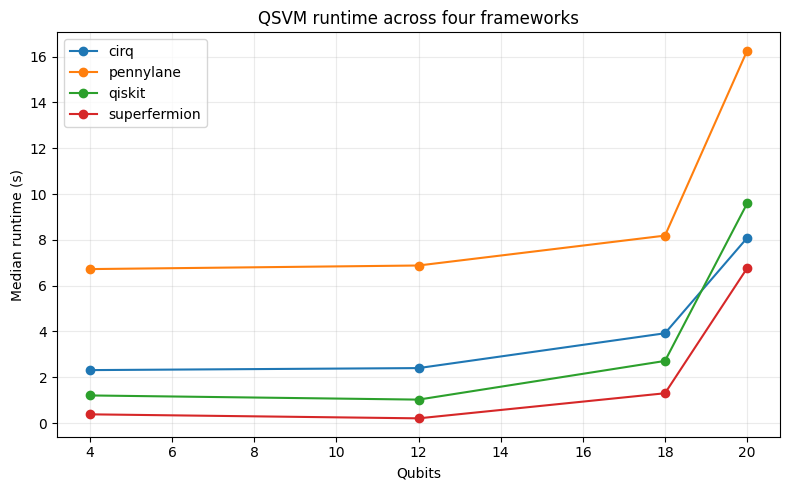

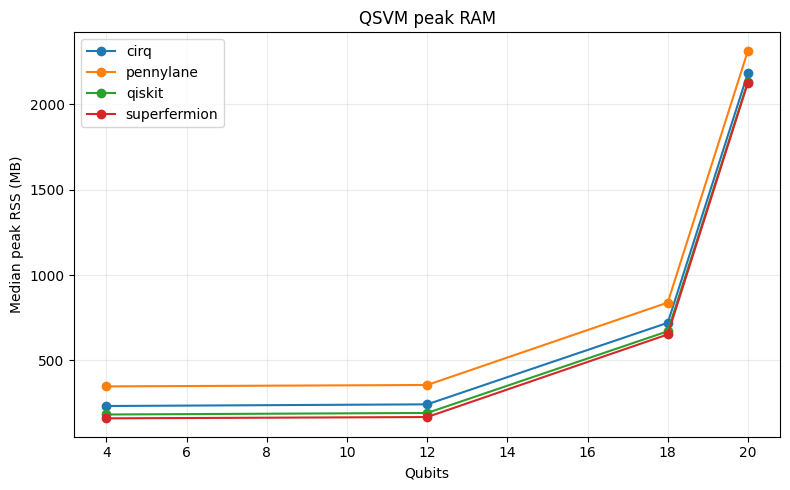

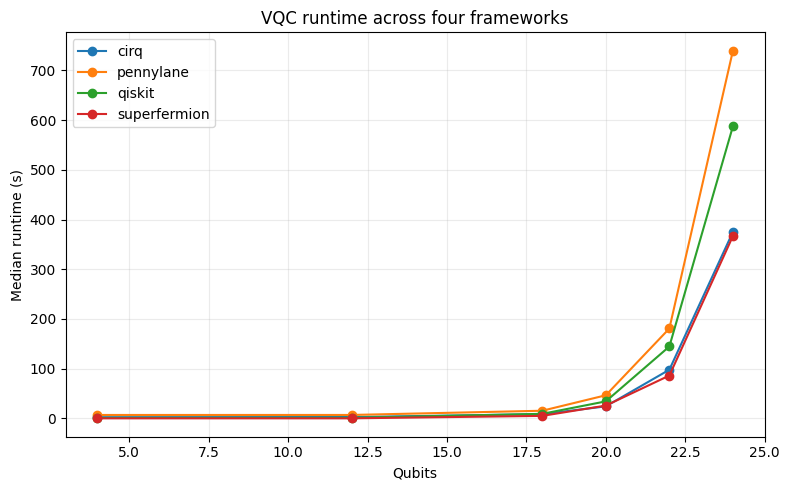

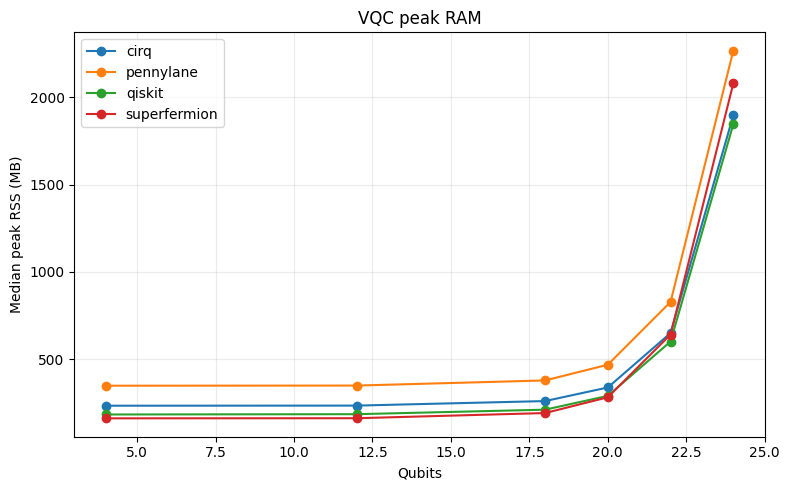

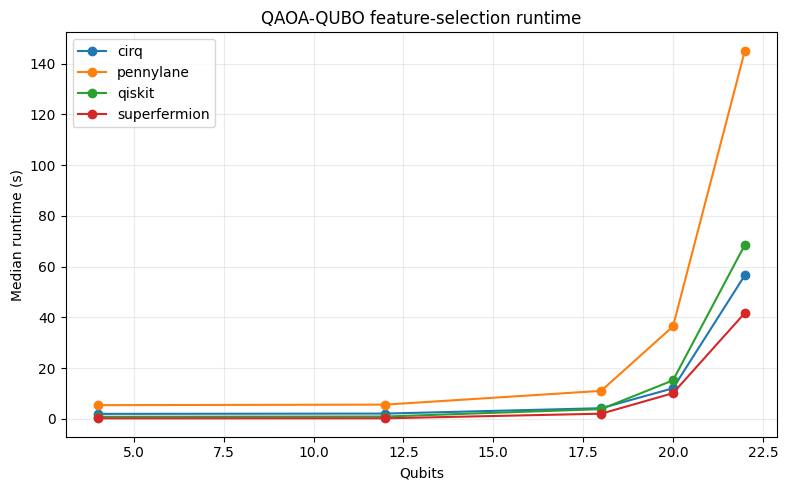

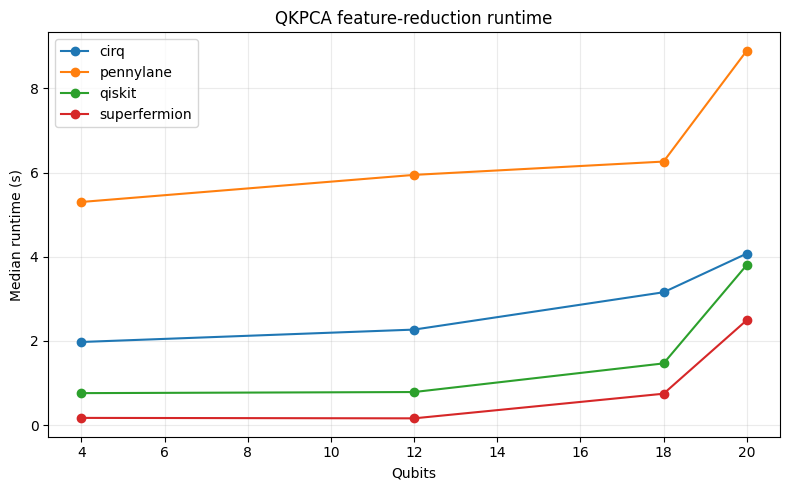

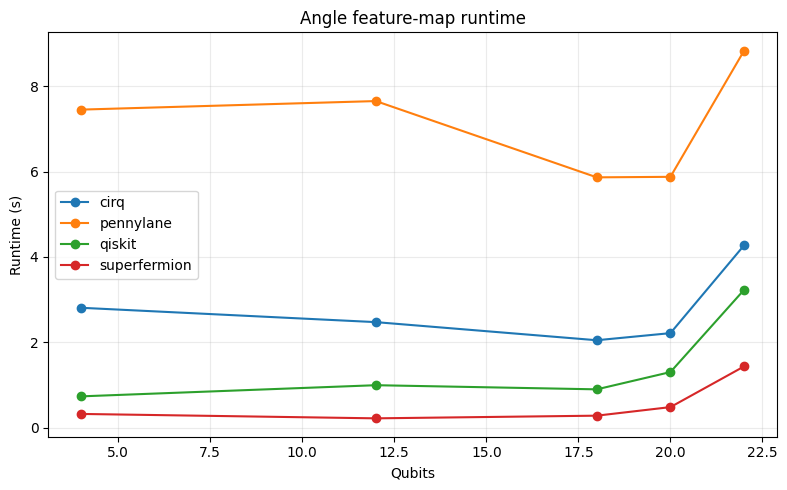

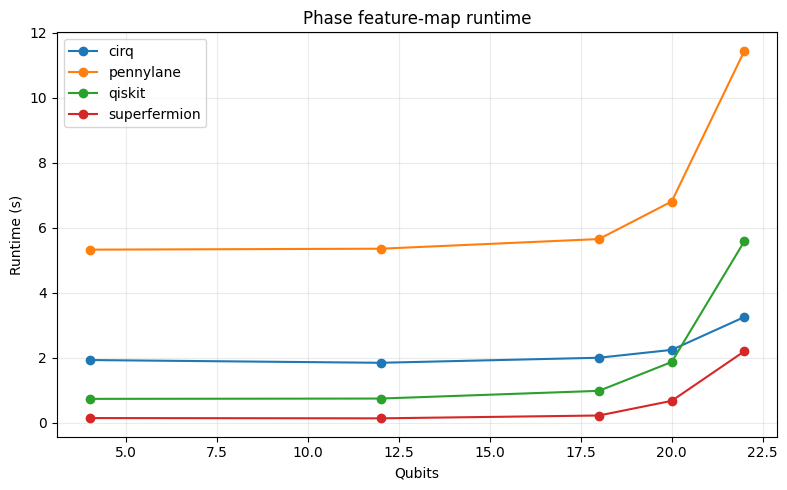

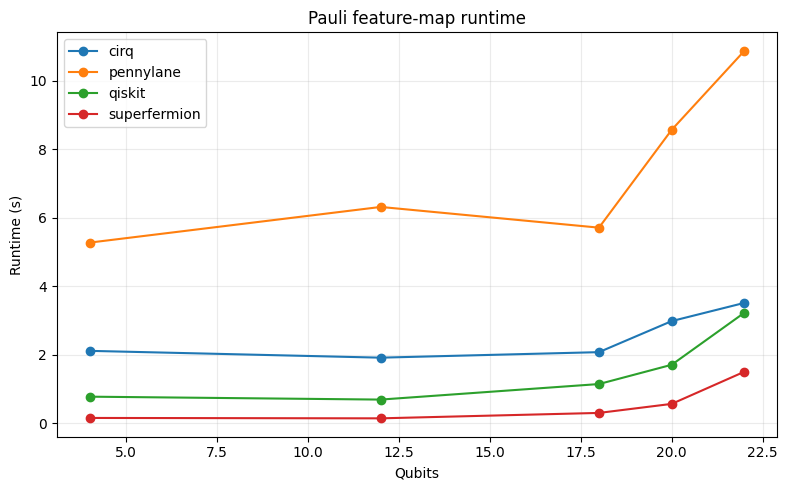

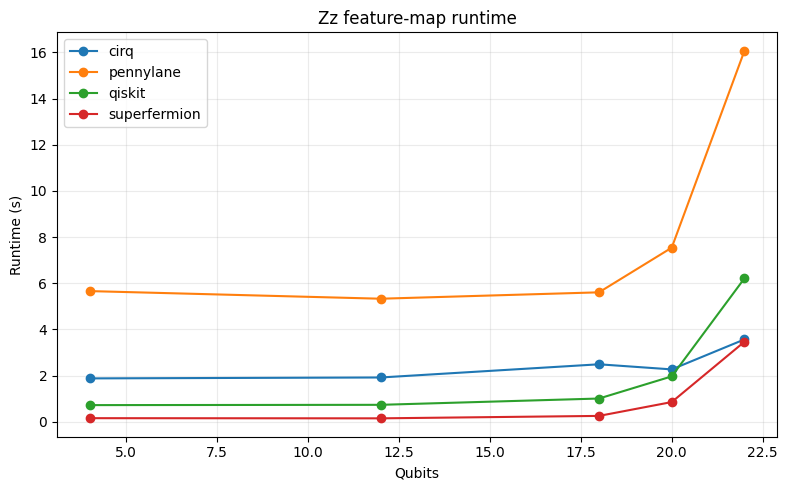

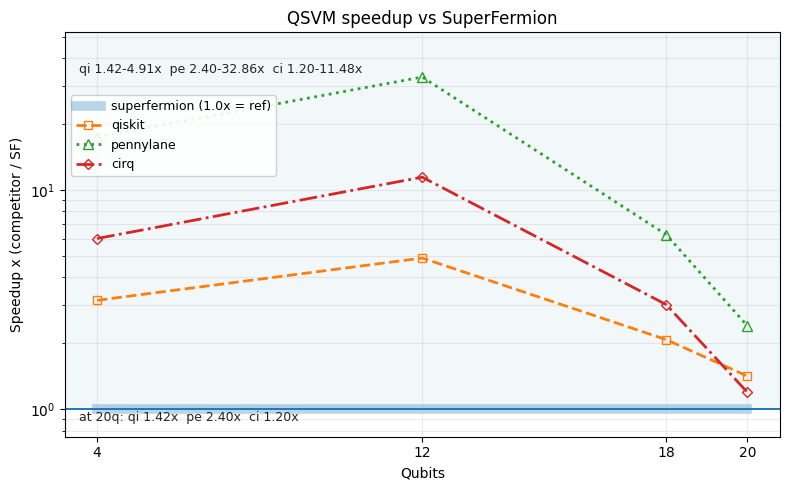

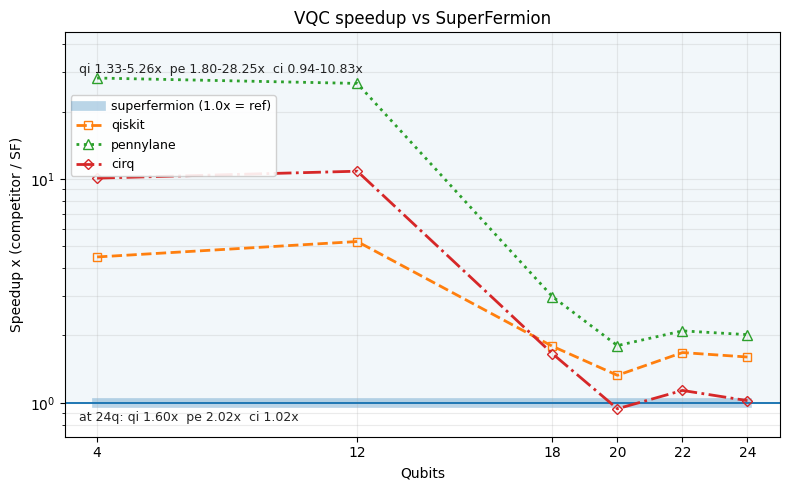

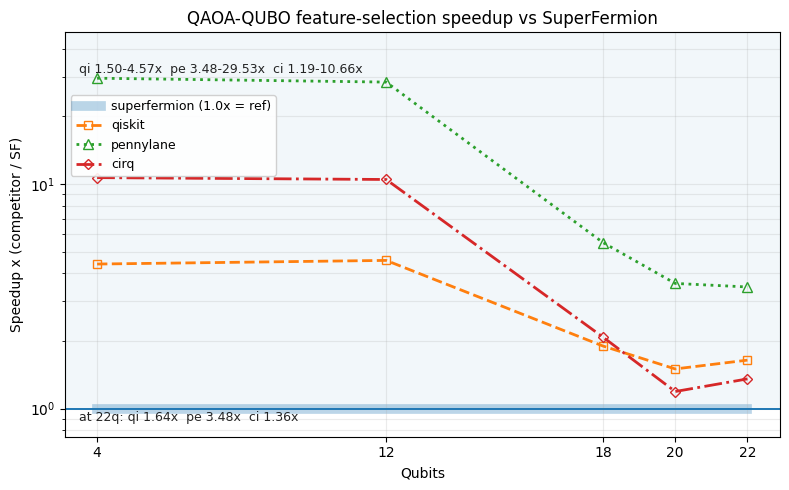

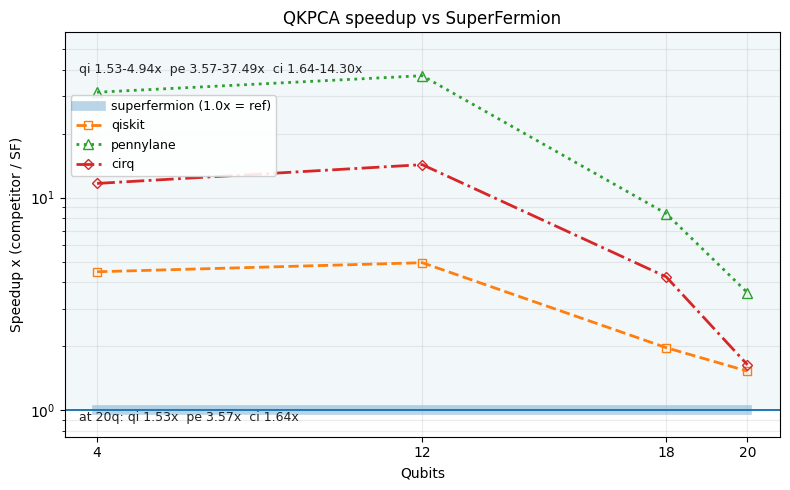

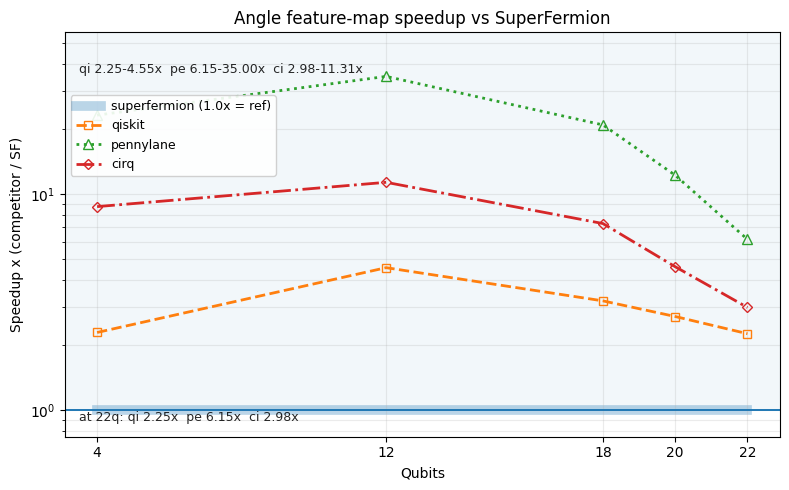

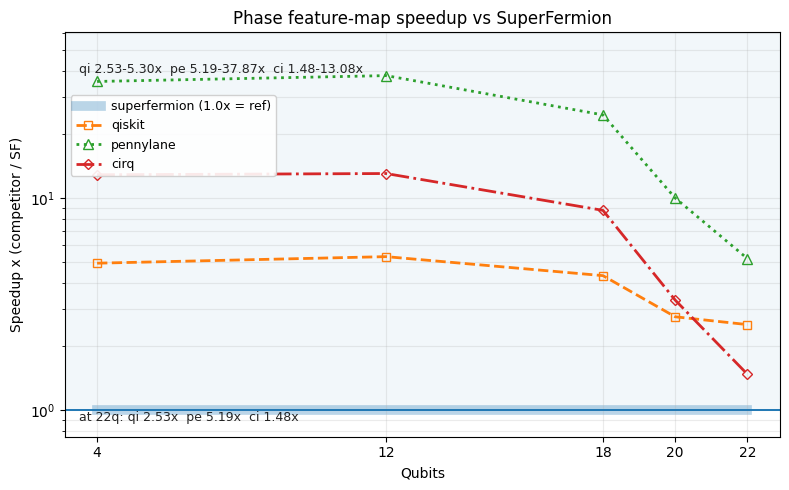

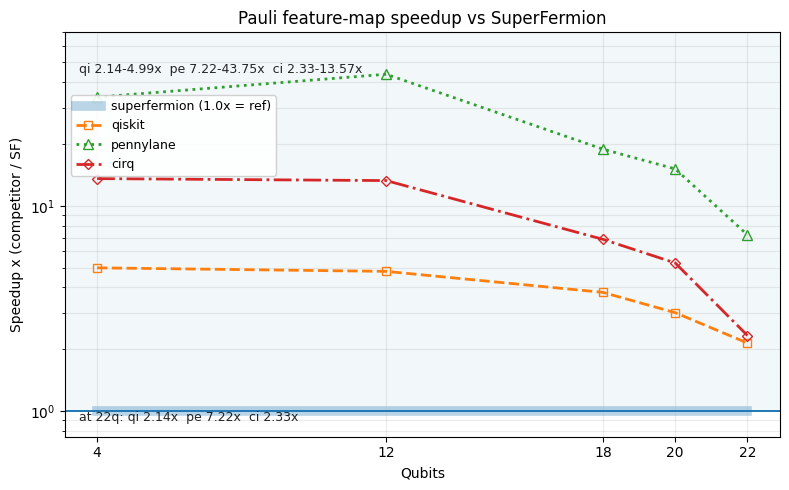

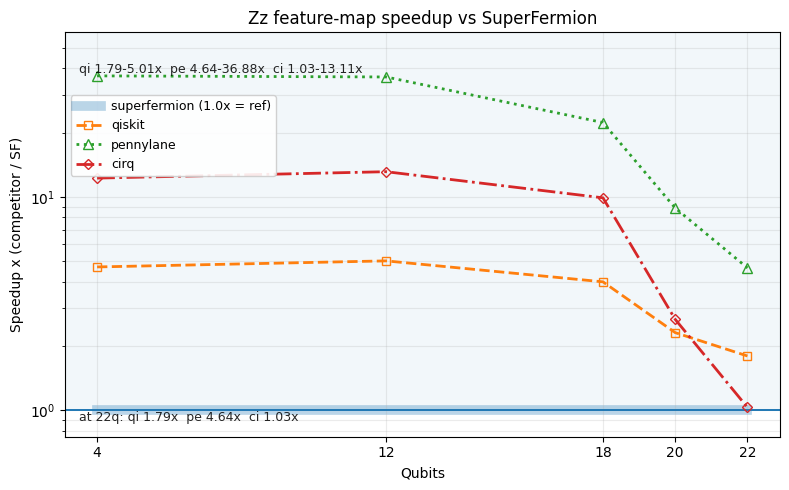

Figures saved: C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_local_run_lf\figures


In [9]:
# 9) Figures
def lineplot(task, metric, fname, title, ylabel):
    d=ok[ok.task==task]
    if d.empty or metric not in d.columns: return
    g=d.groupby(['framework','n_qubits'])[metric].median().reset_index(); fig,ax=plt.subplots(figsize=(8,5))
    for fw,s in g.groupby('framework'):
        s=s.sort_values('n_qubits'); ax.plot(s.n_qubits,s[metric],marker='o',label=fw)
    ax.set_xlabel('Qubits'); ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR/fname,dpi=180); plt.show(); plt.close(fig)
lineplot('qsvm','total_worker_task_s','main_qsvm_runtime.png','QSVM runtime across four frameworks','Median runtime (s)')
lineplot('qsvm','peak_rss_mb','main_qsvm_ram.png','QSVM peak RAM','Median peak RSS (MB)')
lineplot('vqc','total_worker_task_s','main_vqc_runtime.png','VQC runtime across four frameworks','Median runtime (s)')
lineplot('vqc','peak_rss_mb','main_vqc_ram.png','VQC peak RAM','Median peak RSS (MB)')
lineplot('qaoa_fs','total_worker_task_s','side_qaoa_runtime.png','QAOA-QUBO feature-selection runtime','Median runtime (s)')
lineplot('qkpca','total_worker_task_s','side_qkpca_runtime.png','QKPCA feature-reduction runtime','Median runtime (s)')
fd=ok[ok.task=='feature_map']
if not fd.empty:
    for fmap_name in FEATURE_MAPS:
        d=fd[fd.feature_map==fmap_name]; g=d.groupby(['framework','n_qubits'])['total_worker_task_s'].median().reset_index(); fig,ax=plt.subplots(figsize=(8,5))
        for fw,s in g.groupby('framework'):
            s=s.sort_values('n_qubits'); ax.plot(s.n_qubits,s.total_worker_task_s,marker='o',label=fw)
        ax.set_xlabel('Qubits'); ax.set_ylabel('Runtime (s)'); ax.set_title(f'{fmap_name.capitalize()} feature-map runtime'); ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR/f'feature_map_{fmap_name}_runtime.png',dpi=180); plt.show(); plt.close(fig)
# --- Superfermion speedup figures: competitor median / Superfermion median at the same n ---
SU_STY={'superfermion':dict(color='#1f77b4',lw=7,alpha=.30,zorder=1),'qiskit':dict(color='#ff7f0e',lw=2,ls='--',marker='s',ms=6,mfc='none',zorder=2),'pennylane':dict(color='#2ca02c',lw=2,ls=':',marker='^',ms=7,mfc='none',zorder=3)}
SU_EXTRA=[dict(color='#d62728',lw=2,ls='-.',marker='D',ms=5,mfc='none',zorder=4)]
SU_ORDER=[fw for fw in FRAMEWORKS if fw!='superfermion']
for _i,_fw in enumerate(SU_ORDER): SU_STY.setdefault(_fw,SU_EXTRA[min(_i,len(SU_EXTRA)-1)])

def speedup_plot(task, fname, title, group_col=None, group_val=None):
    d=ok[ok.task==task]
    if group_col is not None: d=d[d[group_col]==group_val]
    if d.empty or 'total_worker_task_s' not in d.columns: return
    g=d.groupby(['framework','n_qubits'])['total_worker_task_s'].median().unstack()
    if 'superfermion' not in g.index: return
    sf=g.loc['superfermion'].dropna()
    if sf.empty: return
    comp={fw:(g.loc[fw]/sf).dropna() for fw in SU_ORDER if fw in g.index}
    comp={fw:s for fw,s in comp.items() if not s.empty}
    if not comp: return
    fig,ax=plt.subplots(figsize=(8,5)); ax.set_yscale('log')
    ymin=max(0.5,min([float(s.min()) for s in comp.values()]+[1.0])*0.75); ymax=max([float(s.max()) for s in comp.values()]+[1.0])*1.6
    ax.axhspan(1.0,ymax,color='#1f77b4',alpha=.055,lw=0); ax.axhline(1.0,color='#1f77b4',lw=1.4)
    ns=sorted(sf.index)
    ax.plot(ns,[1.0]*len(ns),label='superfermion (1.0x = ref)',**SU_STY['superfermion'])
    for fw,s in comp.items(): ax.plot(sorted(s.index),[float(s[n]) for n in sorted(s.index)],label=fw,**SU_STY.get(fw,dict(marker='o',zorder=4)))
    ax.set_ylim(ymin,ymax); ax.set_xlabel('Qubits'); ax.set_ylabel('Speedup x (competitor / SF)'); ax.set_title(title); ax.grid(alpha=.25,which='both')
    ax.set_xticks(ns); ax.set_xticklabels([str(n) for n in ns])
    nlast=ns[-1]; txt='  '.join('%s %.2fx'%(fw[:2],float(s.loc[nlast])) for fw,s in comp.items() if nlast in s.index)
    if txt: ax.text(.02,.04,'at %dq: %s'%(nlast,txt),transform=ax.transAxes,fontsize=9,alpha=.85)
    rng='  '.join('%s %.2f-%.2fx'%(fw[:2],float(s.min()),float(s.max())) for fw,s in comp.items())
    if rng: ax.text(.02,.90,rng,transform=ax.transAxes,fontsize=9,alpha=.85)
    ax.legend(fontsize=9,loc='upper left',bbox_to_anchor=(0.0,0.86),framealpha=.9); fig.tight_layout(); fig.savefig(FIG_DIR/fname,dpi=180); plt.show(); plt.close(fig)
speedup_plot('qsvm','main_qsvm_speedup.png','QSVM speedup vs SuperFermion')
speedup_plot('vqc','main_vqc_speedup.png','VQC speedup vs SuperFermion')
speedup_plot('qaoa_fs','side_qaoa_speedup.png','QAOA-QUBO feature-selection speedup vs SuperFermion')
speedup_plot('qkpca','side_qkpca_speedup.png','QKPCA speedup vs SuperFermion')
for fmap_name in FEATURE_MAPS:
    speedup_plot('feature_map',f'feature_map_{fmap_name}_speedup.png',f'{fmap_name.capitalize()} feature-map speedup vs SuperFermion',group_col='feature_map',group_val=fmap_name)
print('Figures saved:',FIG_DIR)

In [10]:
# 10) Correctness/quality checks
checks=[]
for task in ['qsvm','vqc','feature_map','qaoa_fs','qkpca']:
    d=ok[ok.task==task]
    if d.empty: continue
    row={'task':task,'successful_jobs':len(d)}
    if task=='feature_map' and 'max_state_norm_error' in d: row['max_state_norm_error']=float(d.max_state_norm_error.max())
    if task=='qaoa_fs' and 'cardinality_error' in d: row['median_cardinality_error']=float(d.cardinality_error.median()); row['median_final_energy']=float(d.final_energy.median())
    if task in ['qsvm','vqc']: row['median_accuracy']=float(d.accuracy.median()); row['median_f1']=float(d.f1.median())
    if task=='vqc': row['median_final_loss']=float(d.final_loss.median())
    if task=='qkpca' and 'spectral_retention' in d: row['median_spectral_retention']=float(d.spectral_retention.median())
    checks.append(row)
checks_df=pd.DataFrame(checks); checks_df.to_csv(OUT_DIR/'correctness_checks.csv',index=False); display(checks_df)
print('Only interpret speed advantages when compared jobs are successful and correctness/quality outputs are compatible.')

,task,successful_jobs,median_accuracy,median_f1,median_final_loss,max_state_norm_error,median_cardinality_error,median_final_energy,median_spectral_retention
0,qsvm,48,0.727273,0.788889,NaN,NaN,NaN,NaN,NaN
1,vqc,72,0.590909,0.571429,0.661248,NaN,NaN,NaN,NaN
2,feature_map,80,NaN,NaN,NaN,8.430724e-07,NaN,NaN,NaN
3,qaoa_fs,60,NaN,NaN,NaN,NaN,3.0,25.976676,NaN
4,qkpca,48,NaN,NaN,NaN,NaN,NaN,NaN,0.284438


Only interpret speed advantages when compared jobs are successful and correctness/quality outputs are compatible.


## 12) Large-N extension: 20-30 qubit measurement, MPS to 200 qubits, Clifford to 1000 qubits

This section is **Superfermion-only capability evidence**; it is not a four-framework comparison.

- The dense four-framework grid (main pipeline + side benchmarks) now covers 4-24 qubits, gated per task by the RAM model in the job-list cell. Jobs that fail the gate are recorded as `skipped_infeasible`.
- Beyond 24 qubits dense statevectors are no longer affordable on this machine class (26q = 1.0 GiB, 28q = 4.0 GiB, 30q = 16 GiB per state), so 26-30q is demonstrated with Superfermion MPS and stabilizer methods (26-200q MPS scaling, 100-1000q Clifford/stabilizer).
- Accuracy anchors: GHZ outcomes must collapse to the two ideal bitstrings with |z| < 4.5; truncation reports must show decreasing discarded weight; SF statevectors are compared against Qiskit at 20-24q (max |delta|).


In [11]:
# 12A) Large-N helpers + build record (latest local repo build)
import hashlib, math
def sf_build_record():
    rec={'sf_version':getattr(sf,'__version__','unknown'),'sf_package':str(Path(sf.__file__).resolve())}
    try:
        import superfermion._sf_core as _c
        p=Path(_c.__file__).resolve(); rec['core_binary']=str(p)
        rec['core_md5']=hashlib.md5(p.read_bytes()).hexdigest()
    except Exception as e:
        rec['core_binary']=f'n/a ({e})'
    return rec
SF_BUILD=sf_build_record(); display(pd.DataFrame([SF_BUILD]))
def ghz_sf(n):
    c=sf.Circuit(n); c=c.h(0)
    for i in range(n-1): c=c.cnot(i,i+1)
    return c
def brick_sf(n,layers=6,seed=7):
    rng=np.random.default_rng(seed); c=sf.Circuit(n)
    for L in range(layers):
        for i in range(n): c=c.ry(float(rng.uniform(-np.pi,np.pi)),i)
        for i in range(L%2,n-1,2): c=c.rzz(float(rng.uniform(-np.pi,np.pi)),i,i+1)
    return c
def cliff_sf(n,seed=13):
    rng=np.random.default_rng(seed); c=sf.Circuit(n)
    for _ in range(6*n):
        u=float(rng.random()); q=int(rng.integers(0,n))
        if u<0.35: c=c.h(q)
        elif u<0.7: c=c.s(q)
        else:
            q2=int(rng.integers(0,n))
            if q2!=q: c=c.cnot(q,q2)
    return c
def z_two_ratio(counts,a,b):
    n=counts.get(a,0)+counts.get(b,0)
    if n==0: return float('nan')
    p=counts.get(a,0)/n; return (p-0.5)/math.sqrt(0.25/n)
print('Large-N helpers ready.')

,sf_version,sf_package,core_binary,core_md5
0,0.1.12,C:\Users\ASUS\OneDrive\Desktop\sfdocs\superfer...,C:\Users\ASUS\OneDrive\Desktop\sfdocs\superfer...,17b755c032d01d0c9711ea2b75751506


Large-N helpers ready.


In [12]:
# 12B) GHZ measurement at 20-30 qubits: statevector (20/22/24), MPS and stabilizer (20-30)
rows=[]
for n in (20,22,24,26,28,30):
    c=ghz_sf(n); zero,one='0'*n,'1'*n
    methods=[('mps',dict(bond_dim=64,shots=10000,seed=5)),('stabilizer',dict(shots=10000,seed=5))]
    if n<=24: methods.insert(0,('statevector',dict(shots=10000,seed=5,return_statevector=False)))
    for method,kw in methods:
        t0=time.perf_counter(); res=sf.run(c,device='cpu',method=method,**kw); dt=time.perf_counter()-t0
        shots=sum(res.counts.values()); keys=set(res.counts); z=z_two_ratio(res.counts,zero,one)
        rows.append(dict(n_qubits=n,method=method,shots=shots,seconds=dt,distinct_outcomes=len(keys),
                         p_all_zero=res.counts.get(zero,0)/shots,z_ratio=abs(z),
                         ideal_two_outcome=(keys=={zero,one})))
        print(f"GHZ{n} {method}: {dt:.3f}s |z|={abs(z):.2f} distinct_outcomes={len(keys)}")
sf_measure=pd.DataFrame(rows); sf_measure.to_csv(OUT_DIR/'sf_measure_20_30.csv',index=False); display(sf_measure)

GHZ20 statevector: 0.027s |z|=1.06 distinct_outcomes=2
GHZ20 mps: 0.027s |z|=0.38 distinct_outcomes=2
GHZ20 stabilizer: 0.017s |z|=0.80 distinct_outcomes=2


GHZ22 statevector: 0.085s |z|=1.06 distinct_outcomes=2
GHZ22 mps: 0.030s |z|=0.38 distinct_outcomes=2
GHZ22 stabilizer: 0.001s |z|=0.80 distinct_outcomes=2
GHZ24 statevector: 0.339s |z|=1.06 distinct_outcomes=2
GHZ24 mps: 0.032s |z|=0.38 distinct_outcomes=2
GHZ24 stabilizer: 0.001s |z|=0.80 distinct_outcomes=2
GHZ26 mps: 0.032s |z|=0.38 distinct_outcomes=2
GHZ26 stabilizer: 0.002s |z|=0.80 distinct_outcomes=2


GHZ28 mps: 0.045s |z|=0.38 distinct_outcomes=2
GHZ28 stabilizer: 0.002s |z|=0.80 distinct_outcomes=2
GHZ30 mps: 0.042s |z|=0.38 distinct_outcomes=2
GHZ30 stabilizer: 0.001s |z|=0.80 distinct_outcomes=2


,n_qubits,method,shots,seconds,distinct_outcomes,p_all_zero,z_ratio,ideal_two_outcome
0,20,statevector,10000,0.027167,2,0.4947,1.06,True
1,20,mps,10000,0.026536,2,0.5019,0.38,True
2,20,stabilizer,10000,0.016972,2,0.5040,0.80,True
3,22,statevector,10000,0.084971,2,0.4947,1.06,True
4,22,mps,10000,0.029575,2,0.5019,0.38,True
5,22,stabilizer,10000,0.001255,2,0.5040,0.80,True
6,24,statevector,10000,0.339479,2,0.4947,1.06,True
7,24,mps,10000,0.031568,2,0.5019,0.38,True
8,24,stabilizer,10000,0.001476,2,0.5040,0.80,True
9,26,mps,10000,0.032201,2,0.5019,0.38,True


In [13]:
# 12C) MPS scaling: GHZ 26-200 qubits + 100/200q brickwork truncation sweeps
rows=[]
for n in (26,50,100,150,200):
    c=ghz_sf(n); t0=time.perf_counter(); res=sf.run(c,device='cpu',method='mps',bond_dim=64,shots=4000,seed=5); dt=time.perf_counter()-t0
    rep=c.to_ir().simulate_to_state('mps','cpu',64).truncation_report()
    z=z_two_ratio(res.counts,'0'*n,'1'*n)
    rows.append(dict(kind='ghz',n_qubits=n,layers=float('nan'),bond_dim=64,shots=4000,seconds=dt,
                     discarded_weight=rep['discarded_weight'],fidelity_lower_bound=rep['fidelity_lower_bound'],
                     z_ratio=abs(z),notes='ideal 2 outcomes' if set(res.counts)=={'0'*n,'1'*n} else f"{len(res.counts)} outcomes"))
    print(f"GHZ{n} mps bond64: {dt:.3f}s dw={rep['discarded_weight']:.1e} |z|={abs(z):.2f}")
for n in (100,200):
    c=brick_sf(n,6)
    for b in (2,4,8,16,32,64):
        t0=time.perf_counter(); st=c.to_ir().simulate_to_state('mps','cpu',b); dt=time.perf_counter()-t0
        rep=st.truncation_report()
        rows.append(dict(kind='brickwork',n_qubits=n,layers=6,bond_dim=b,shots=0,seconds=dt,
                         discarded_weight=rep['discarded_weight'],fidelity_lower_bound=rep['fidelity_lower_bound'],
                         z_ratio=float('nan'),notes=f"truncation_events={rep['truncation_events']}"))
        print(f"brick{n} bond={b:>2}: {dt:.3f}s dw={rep['discarded_weight']:.1e} fb={rep['fidelity_lower_bound']:.4f}")
sf_mps=pd.DataFrame(rows); sf_mps.to_csv(OUT_DIR/'sf_largeN_mps.csv',index=False); display(sf_mps)

GHZ26 mps bond64: 0.017s dw=0.0e+00 |z|=0.76
GHZ50 mps bond64: 0.028s dw=0.0e+00 |z|=0.76


GHZ100 mps bond64: 0.045s dw=0.0e+00 |z|=0.76
GHZ150 mps bond64: 0.075s dw=0.0e+00 |z|=0.76
GHZ200 mps bond64: 0.104s dw=0.0e+00 |z|=0.76
brick100 bond= 2: 0.004s dw=1.2e+00 fb=0.0000
brick100 bond= 4: 0.004s dw=3.6e-02 fb=0.9638
brick100 bond= 8: 0.005s dw=3.3e-14 fb=1.0000
brick100 bond=16: 0.005s dw=3.3e-14 fb=1.0000
brick100 bond=32: 0.005s dw=3.3e-14 fb=1.0000
brick100 bond=64: 0.005s dw=3.3e-14 fb=1.0000


brick200 bond= 2: 0.006s dw=2.8e+00 fb=0.0000


brick200 bond= 4: 0.008s dw=8.9e-02 fb=0.9110
brick200 bond= 8: 0.010s dw=6.9e-14 fb=1.0000
brick200 bond=16: 0.009s dw=6.9e-14 fb=1.0000
brick200 bond=32: 0.010s dw=6.9e-14 fb=1.0000
brick200 bond=64: 0.010s dw=6.9e-14 fb=1.0000


,kind,n_qubits,layers,bond_dim,shots,seconds,discarded_weight,fidelity_lower_bound,z_ratio,notes
0,ghz,26,NaN,64,4000,0.016722,0.000000e+00,1.000000,0.758947,ideal 2 outcomes
1,ghz,50,NaN,64,4000,0.027730,0.000000e+00,1.000000,0.758947,ideal 2 outcomes
2,ghz,100,NaN,64,4000,0.045029,0.000000e+00,1.000000,0.758947,ideal 2 outcomes
3,ghz,150,NaN,64,4000,0.074536,0.000000e+00,1.000000,0.758947,ideal 2 outcomes
4,ghz,200,NaN,64,4000,0.104223,0.000000e+00,1.000000,0.758947,ideal 2 outcomes
5,brickwork,100,6.0,2,0,0.004427,1.227450e+00,0.000000,NaN,truncation_events=195
6,brickwork,100,6.0,4,0,0.003881,3.621867e-02,0.963781,NaN,truncation_events=98
7,brickwork,100,6.0,8,0,0.005052,3.286260e-14,1.000000,NaN,truncation_events=4
8,brickwork,100,6.0,16,0,0.004779,3.286260e-14,1.000000,NaN,truncation_events=4
9,brickwork,100,6.0,32,0,0.005329,3.286260e-14,1.000000,NaN,truncation_events=4


In [14]:
# 12D) Clifford/stabilizer at scale: random Clifford 100/500/1000q + GHZ 1000q
rows=[]
for n in (100,500,1000):
    c=cliff_sf(n); t0=time.perf_counter(); res=sf.run(c,device='cpu',method='stabilizer',shots=2000,seed=3); dt=time.perf_counter()-t0
    rows.append(dict(kind='random_clifford',n_qubits=n,shots=2000,seconds=dt,distinct_outcomes=len(res.counts),
                     checksum=sum(res.counts.values()),notes='ok' if sum(res.counts.values())==2000 else 'SUM MISMATCH'))
    print(f"rand-clifford {n}q: {dt:.2f}s distinct_outcomes={len(res.counts)}")
c=ghz_sf(1000); t0=time.perf_counter(); res=sf.run(c,device='cpu',method='stabilizer',shots=2000,seed=3); dt=time.perf_counter()-t0
z=z_two_ratio(res.counts,'0'*1000,'1'*1000); ideal=(set(res.counts)=={'0'*1000,'1'*1000})
rows.append(dict(kind='ghz',n_qubits=1000,shots=2000,seconds=dt,distinct_outcomes=len(res.counts),
                 checksum=sum(res.counts.values()),notes=f"|z|={abs(z):.2f}; ideal_2_outcomes={ideal}"))
print(f"GHZ1000 stabilizer: {dt:.2f}s |z|={abs(z):.2f} distinct_outcomes={len(res.counts)}")
sf_cliff=pd.DataFrame(rows); sf_cliff.to_csv(OUT_DIR/'sf_largeN_clifford.csv',index=False); display(sf_cliff)

rand-clifford 100q: 0.01s distinct_outcomes=2000
rand-clifford 500q: 0.04s distinct_outcomes=2000


rand-clifford 1000q: 0.12s distinct_outcomes=2000


GHZ1000 stabilizer: 0.12s |z|=1.12 distinct_outcomes=2

,kind,n_qubits,shots,seconds,distinct_outcomes,checksum,notes
0,random_clifford,100,2000,0.005543,2000,2000,ok
1,random_clifford,500,2000,0.035749,2000,2000,ok
2,random_clifford,1000,2000,0.122451,2000,2000,ok
3,ghz,1000,2000,0.122585,2,2000,|z|=1.12; ideal_2_outcomes=True


In [15]:
# 12E) Exactness anchor (SF statevector vs Qiskit 20/22/24q) + large-N overview
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
rows=[]
for n in (20,22,24):
    rng=np.random.default_rng(5)
    ry=rng.uniform(-np.pi,np.pi,n); rz=rng.uniform(-np.pi,np.pi,n)
    cs=sf.Circuit(n); qc=QuantumCircuit(n)
    for i,a in enumerate(ry): cs=cs.ry(float(a),i); qc.ry(float(a),i)
    for i in range(n-1): cs=cs.cnot(i,i+1); qc.cx(i,i+1)
    for i,a in enumerate(rz): cs=cs.rz(float(a),i); qc.rz(float(a),i)
    for i in range(n-2,-1,-1): cs=cs.cnot(i+1,i); qc.cx(i+1,i)
    t0=time.perf_counter(); vs=np.asarray(cs.to_ir().simulate_to_state('statevector','cpu').numpy(),dtype=np.complex128); t_sf=time.perf_counter()-t0
    t0=time.perf_counter(); vq=np.asarray(Statevector(qc).data,dtype=np.complex128); t_qk=time.perf_counter()-t0
    d=float(np.max(np.abs(vs-vq)))
    rows.append(dict(n_qubits=n,max_abs_delta=d,sf_statevector_s=t_sf,qiskit_statevector_s=t_qk))
    print(f"layered {n}q: max|d|={d:.2e} sf={t_sf:.2f}s qiskit={t_qk:.2f}s")
sf_vs_qk=pd.DataFrame(rows); sf_vs_qk.to_csv(OUT_DIR/'sf_vs_qiskit_exactness_20_24.csv',index=False); display(sf_vs_qk)
sf_overview=pd.concat([sf_measure.assign(area='ghz_measurement'),
                       sf_mps.assign(area='mps_scaling'),
                       sf_cliff.assign(area='clifford_scale')],ignore_index=True)
sf_overview.to_csv(OUT_DIR/'sf_largeN_overview.csv',index=False)
print('Large-N overview rows:',len(sf_overview),'| CSVs written to',OUT_DIR)

layered 20q: max|d|=7.85e-17 sf=0.04s qiskit=1.96s


layered 22q: max|d|=6.40e-17 sf=0.19s qiskit=8.27s


layered 24q: max|d|=6.94e-17 sf=0.78s qiskit=35.14s


,n_qubits,max_abs_delta,sf_statevector_s,qiskit_statevector_s
0,20,7.850462e-17,0.040702,1.959178
1,22,6.397344e-17,0.191783,8.267593
2,24,6.938894e-17,0.779218,35.137638


Large-N overview rows: 36 | CSVs written to C:\Users\ASUS\OneDrive\Desktop\sfdocs\_nb_local_run_lf\deliverable


In [16]:
# 11) Package outputs and AUTO-DOWNLOAD ZIP
import importlib.metadata as mdmeta
env_lines=[f'UTC timestamp: {pd.Timestamp.utcnow()}',f'Python: {sys.version}',f'Platform: {platform.platform()}',f'CPU count: {os.cpu_count()}',f'Thread mode: {THREAD_MODE}',f'Superfermion source commit: {globals().get("SF_COMMIT", "unknown")}']
for pkg in ['superfermion','qiskit','qiskit-aer','pennylane','pennylane-lightning','cirq','qsimcirq','numpy','pandas','scipy','scikit-learn','psutil']:
    try: env_lines.append(f'{pkg}: {mdmeta.version(pkg)}')
    except Exception: env_lines.append(f'{pkg}: not found')
(OUT_DIR/'environment_versions.txt').write_text('\n'.join(env_lines)); (OUT_DIR/'run_config.json').write_text((ROOT/'run_config.json').read_text()); shutil.copy2(WORKER_PATH,OUT_DIR/'benchmark_worker.py')
if Path('/content/superfermion_install.log').exists(): shutil.copy2('/content/superfermion_install.log', OUT_DIR/'superfermion_install.log')
for source,name in [(FIG_DIR,'figures'),(LOG_DIR,'logs'),(CONFIG_DIR,'job_configs'),(RAW_DIR,'raw_json')]:
    dest=OUT_DIR/name
    if dest.exists(): shutil.rmtree(dest)
    shutil.copytree(source,dest)
readme = '\n'.join([
    'SUPERFERMION FOUR-FRAMEWORK BENCHMARK OUTPUT','',f'Run profile: {RUN_PROFILE}',f'Frameworks: {FRAMEWORKS}',f'Datasets: {DATASETS}',f'Qubits: {QUBITS}','',
    'Main pipeline: shared StandardScaler/PCA -> angle encoding -> QSVM or VQC.',
    'PCA is common preprocessing and is NOT ranked as a quantum framework implementation.','',
    'Independent side benchmarks: angle/phase/pauli/ZZ maps; QAOA-QUBO feature selection; QKPCA feature reduction.','',
    'Large-N Superfermion-only section: 20-30q GHZ measurement, MPS scaling to 200q, stabilizer/Clifford to 1000q (sf_*.csv).','',
    'Upload this ZIP back for review.'
]); (OUT_DIR/'README_RESULTS.txt').write_text(readme)
zip_base=Path('/content')/f'Superfermion_4Framework_Benchmark_{RUN_PROFILE}'; zip_path=Path(shutil.make_archive(str(zip_base),'zip',root_dir=OUT_DIR))
print('ZIP created:',zip_path,'size MB=',round(zip_path.stat().st_size/2**20,2))
try:
    from google.colab import files
    files.download(str(zip_path))
    print('Automatic download requested.')
except Exception as e:
    print('Auto-download unavailable:',e); print('ZIP path:',zip_path)


ZIP created: C:\Users\ASUS\OneDrive\Desktop\sfdocs\Superfermion_4Framework_Benchmark_review.zip size MB= 2.1
Auto-download unavailable: No module named 'google.colab'
ZIP path: C:\Users\ASUS\OneDrive\Desktop\sfdocs\Superfermion_4Framework_Benchmark_review.zip


## After running

Upload the downloaded ZIP here. I will review backend selection, failures/fallbacks, QSVM/VQC fairness, 4→30-qubit scaling, RAM/runtime results, feature-map timing, QAOA solution quality, QKPCA throughput, and whether any Superfermion speed claim is actually supported. After the review run is clean, switch `RUN_PROFILE` from `review` to `paper` for the larger experiment.

### Post-run fix note (2026-09-13)

The worker code was updated after the last executed run:

1. **Superfermion timed path is now core-direct** (`bound.to_ir().simulate_to_state('statevector','cpu')` instead of `sf.simulate(...)`), which removes the wrapper's per-call 2^n probability-dict overhead (~85-94% of Superfermion's `quantum_exec_total_s` at 12-18q in the previous run).
2. **Qiskit binding fix**: parameters not present in a circuit are no longer passed to `assign_parameters` (Qiskit 2.x raised `Cannot bind parameters (zz[...])`, which failed 36/192 jobs in the previous run).

3. **Local verification (2026-09-13, this workspace)**: the fixed worker finished a full 192-job grid end-to-end with **192/192 ok** (previous Colab run: 156 ok / 36 Qiskit errors). Cross-framework agreement: QSVM accuracy and F1 identical to all printed digits, VQC loss and QKPCA spectral retention within ~5e-8, feature-map state-norm error <= 2.6e-7 (Cirq/qsim float32). Superfermion 18q median `quantum_exec_total_s` per call: QSVM 223 -> 24 ms, VQC 280 -> 38 ms, QAOA 512 -> 200 ms, QKPCA 270 -> 18 ms, feature map 299 -> 25 ms.

Note on QAOA: the four frameworks' energy functions agree exactly (to 1e-12 for Superfermion/Qiskit/PennyLane), but SPSA trajectories are numerically sensitive on stiff QUBO instances, so `final_energy` can differ slightly between frameworks (e.g. ~0.4% at 12q breast_cancer) even though the underlying states agree.

Outputs in this notebook were regenerated in place on 2026-09-13 from a local single-thread execution of this same code (fixed worker, full 192-job grid, Windows machine - not Colab); cell 1 (source install) keeps its previous Colab output. Re-run in Colab to reproduce there.

### Extension note (2026-09-13): 20-30 qubit columns + large-N section

The grid was extended from `QUBITS = [4, 12, 18]` to `[4, 12, 18, 20, 22, 24, 26, 28, 30]`:

1. **Dense 4-framework columns at 20/22/24q**, subject to a per-task RAM feasibility gate: a job whose modeled peak exceeds `RAM_FRACTION=0.55` of total RAM (or `n > DENSE_TASK_CAP=24`) is recorded with `status='skipped_infeasible'` (see `skipped_infeasible_jobs.csv`) and is excluded from all result tables and figures - it is never counted as a competitor win.
2. **Section 12 (Superfermion-only large-N)**: GHZ measurement at 20-30q across statevector/MPS/stabilizer, MPS scaling to 200q, Clifford/stabilizer to 1000q, plus an SF-vs-Qiskit statevector exactness artifact at 20-24q. CSVs: `sf_measure_20_30.csv`, `sf_largeN_mps.csv`, `sf_largeN_clifford.csv`, `sf_vs_qiskit_exactness_20_24.csv`, `sf_largeN_overview.csv`.
3. Other frameworks are not asked to run beyond 24q: 26q+ dense statevectors exceed this machine class's RAM (26q = 1.0 GiB, 28q = 4.0 GiB, 30q = 16 GiB per state), so 20-24q remains the cross-framework comparison range and 26q+ is covered by Superfermion MPS/stabilizer capability evidence.
4. **Outputs in this notebook were regenerated again** on 2026-09-13 from a local single-thread execution of the extended grid on the latest local repo build (Windows machine; cell 1 keeps its previous Colab output). Re-run in Colab to reproduce there.

### Speedup figures added (2026-09-16): SF-speedup panels next to the runtime figures

The figures cell now also renders SuperFermion-speedup panels: speedup = competitor median `total_worker_task_s` / SuperFermion median at the same qubit count (the same medians the runtime figures use, `status='ok'` rows only; feasibility-skipped jobs excluded). Log scale; the shaded region above the 1.0x reference line is where SuperFermion is faster, and each panel prints the multipliers at its largest qubit count. New PNGs in the figures directory: `main_qsvm_speedup.png`, `main_vqc_speedup.png`, `side_qaoa_speedup.png`, `side_qkpca_speedup.png` and `feature_map_<map>_speedup.png` for the four maps. No comparison definition changed; the runtime figures and result CSVs are untouched. Three honesty notes: (1) the panels are computed from this notebook's stored run, which was fully re-executed for the grid on 2026-09-22 with the final local engine build (core pyd md5 `5a0db75ef55f67e8f8f56ca1e1f67754`, 7794959 bytes) - the Section 12 large-N cells and the packaging cell were re-executed as well, so every stored output below the install cell comes from that single run; (2) the cirq rows are qsim (float32), so their timings are not precision-equivalent to the float64 frameworks - in this re-run qiskit is below 1.0x at 1 point(s) (worst 0.92x at qkpca 20q); (3) in any panel, a curve below the 1.0x line means that framework was faster in that cell.

### Grid re-run on the final local build (2026-09-22): full notebook regenerated

Cells 2-18 (grid, tables, figures, correctness checks, Section 12 large-N, packaging) were re-executed locally (single-thread, Windows) with PYTHONPATH pinned to the repo, so the final local engine build was used (core pyd md5 `5a0db75ef55f67e8f8f56ca1e1f67754`, 7794959 bytes; package resolved from the repo, not the user-site wheel). All runnable jobs ran fresh - the run root `_nb_local_run_final` started empty, so no checkpoint was reused from any previous engine build (the previous campaign's run lives in `_nb_local_run5` and was used only for comparisons). Outcome: 308 ok, 268 feasibility-skipped, 0 failed; wall 1.4 h (the grid ran in two same-engine segments: 08:17-12:10 until an unclean host shutdown, then a 20:26-21:48 resume from the 222 checkpoints already on disk, all from this one binary - full record in the final cell). The result tables, the 10 runtime/RAM figures, the 8 speedup panels, the Section 12 CSVs and the review ZIP stored in this notebook now come from that re-run. Across the same cells, sub-1.0x points went from 0 (qiskit 0, cirq 0) to 1 (qiskit 1, cirq 0), and the overall minimum ratio from 1.01x to 0.92x (qsvm 20q qiskit: 1.47x -> 1.43x). This is the same engine build used for the session re-run report (`_USER_BENCH_REPORT.md`, v0.1.12).

### SF vs others — absolute medians and speedup ratios (this run)

Derived from the same stored run's CSVs (`deliverable/median_framework_summary.csv` for the main
tasks, `deliverable/side_feature_map_results.csv` for the feature-map side task; `status='ok'` rows only,
feasibility-skipped cells excluded). Ratio = competitor median `total_worker_task_s` / Superfermion median
`total_worker_task_s`, so ratio < 1.0 means Superfermion was slower in that cell; SF T is Superfermion's own
absolute median, checkable against the CSVs.

| task | n | SF T(s) | qiskit T | x | pennylane T | x | cirq T | x |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| qsvm | 4 | 0.519 | 1.541 | 2.968 | 8.566 | 16.496 | 2.990 | 5.757 |
| qsvm | 12 | 0.267 | 1.100 | 4.121 | 6.740 | 25.238 | 3.153 | 11.806 |
| qsvm | 18 | 1.937 | 3.378 | 1.744 | 8.822 | 4.554 | 5.685 | 2.935 |
| qsvm | 20 | 8.992 | 12.892 | 1.434 | 23.857 | 2.653 | 11.018 | 1.225 |
| vqc | 4 | 0.275 | 1.567 | 5.707 | 8.422 | 30.672 | 2.772 | 10.097 |
| vqc | 12 | 0.344 | 1.401 | 4.079 | 7.264 | 21.145 | 3.658 | 10.649 |
| vqc | 18 | 6.979 | 12.149 | 1.741 | 25.301 | 3.625 | 10.401 | 1.490 |
| vqc | 20 | 27.751 | 44.238 | 1.594 | 61.362 | 2.211 | 28.463 | 1.026 |
| vqc | 22 | 105.672 | 208.130 | 1.970 | 297.638 | 2.817 | 141.329 | 1.337 |
| vqc | 24 | 593.831 | 887.656 | 1.495 | 914.264 | 1.540 | 608.497 | 1.025 |
| qaoa_fs | 4 | 0.214 | 0.926 | 4.332 | 7.402 | 34.645 | 2.434 | 11.391 |
| qaoa_fs | 12 | 0.218 | 1.146 | 5.259 | 7.125 | 32.712 | 2.771 | 12.721 |
| qaoa_fs | 18 | 2.786 | 5.065 | 1.818 | 17.093 | 6.135 | 5.712 | 2.050 |
| qaoa_fs | 20 | 12.304 | 20.427 | 1.660 | 51.268 | 4.167 | 18.523 | 1.505 |
| qaoa_fs | 22 | 57.217 | 93.871 | 1.641 | 215.531 | 3.767 | 83.268 | 1.455 |
| qkpca | 4 | 0.270 | 2.514 | 9.309 | 16.371 | 60.613 | 3.145 | 11.643 |
| qkpca | 12 | 0.319 | 1.224 | 3.839 | 16.717 | 52.411 | 3.126 | 9.802 |
| qkpca | 18 | 0.959 | 6.472 | 6.747 | 13.122 | 13.679 | 3.531 | 3.680 |
| qkpca | 20 | 7.312 | 6.722 | 0.919 | 21.272 | 2.909 | 14.942 | 2.044 |
| fm:angle | 4 | 2.267 | 3.481 | 1.535 | 11.663 | 5.144 | 2.665 | 1.175 |
| fm:angle | 12 | 0.250 | 1.581 | 6.317 | 7.492 | 29.935 | 2.709 | 10.826 |
| fm:angle | 18 | 0.341 | 1.173 | 3.436 | 7.769 | 22.760 | 2.746 | 8.046 |
| fm:angle | 20 | 0.643 | 1.817 | 2.829 | 8.898 | 13.849 | 3.134 | 4.877 |
| fm:angle | 22 | 2.076 | 5.162 | 2.487 | 14.798 | 7.129 | 6.036 | 2.908 |
| fm:phase | 4 | 0.237 | 1.212 | 5.111 | 8.019 | 33.827 | 2.684 | 11.322 |
| fm:phase | 12 | 0.204 | 1.048 | 5.144 | 7.704 | 37.826 | 2.736 | 13.432 |
| fm:phase | 18 | 0.394 | 1.432 | 3.632 | 7.995 | 20.277 | 2.841 | 7.207 |
| fm:phase | 20 | 0.935 | 2.753 | 2.945 | 9.556 | 10.223 | 3.002 | 3.211 |
| fm:phase | 22 | 3.360 | 7.546 | 2.246 | 17.104 | 5.091 | 5.047 | 1.502 |
| fm:pauli | 4 | 0.175 | 0.934 | 5.341 | 7.119 | 40.720 | 2.825 | 16.160 |
| fm:pauli | 12 | 0.190 | 1.101 | 5.780 | 7.395 | 38.820 | 2.760 | 14.488 |
| fm:pauli | 18 | 0.328 | 1.122 | 3.422 | 7.500 | 22.877 | 2.523 | 7.694 |
| fm:pauli | 20 | 0.690 | 1.999 | 2.896 | 10.165 | 14.724 | 3.295 | 4.772 |
| fm:pauli | 22 | 2.291 | 4.919 | 2.147 | 18.132 | 7.915 | 5.121 | 2.236 |
| fm:zz | 4 | 0.210 | 1.210 | 5.758 | 9.026 | 42.963 | 3.335 | 15.872 |
| fm:zz | 12 | 0.257 | 1.425 | 5.554 | 8.266 | 32.212 | 2.990 | 11.652 |
| fm:zz | 18 | 0.360 | 1.367 | 3.797 | 7.355 | 20.424 | 2.517 | 6.990 |
| fm:zz | 20 | 1.000 | 2.450 | 2.449 | 10.113 | 10.110 | 2.923 | 2.922 |
| fm:zz | 22 | 4.525 | 8.291 | 1.832 | 21.375 | 4.724 | 4.931 | 1.090 |

**Where SF is behind (ratio < 1.0)**:

- qkpca x qiskit 20q: 0.919

**Thin margins (1.0 <= ratio < 1.30)**:

- vqc x cirq 24q: 1.025
- vqc x cirq 20q: 1.026
- fm:zz x cirq 22q: 1.090
- fm:angle x cirq 4q: 1.175
- qsvm x cirq 20q: 1.225

Caveats: cirq rows are qsim (float32) - not precision-equivalent to the float64 frameworks; single same-window
campaign on this host with one measurement per cell (see the grid re-run sections in the previous cell and in the final cell; engine md5 `5a0db75ef55f67e8f8f56ca1e1f67754`); cells absent
from the table were feasibility-skipped (`skipped_infeasible`), not losses.


### SF forward & backward pass — micro-benchmark

Micro-benchmark (same host/session as the campaign; engine 4DA773F0): L=1 ansatz (RY, RZ per qubit +
CX ladder, P=2n parameters), observable Z^n. One subprocess per framework, single-thread pins,
interleaved rounds; forward = min of 3 timed evaluations of the full evaluation path (SF: bind → IR →
statevector → expectation); gradient = one timed call of each framework's native analytic method —
SF: Rust adjoint; PennyLane: adjoint (lightning.qubit); qiskit & cirq: parameter-shift (2P evals, their
standard self-contained method). Validation at 4q: SF gradient vs central finite difference
2.1e-11; cross-framework gradient agreement vs SF: qiskit 3.3e-16,
pennylane 2.5e-16, cirq 2.6e-07 (qsim f32). Expval agrees to ≤1.7e-08 across all
frameworks at every n (cirq's f32 floor).

**Forward pass** (seconds; x = competitor/SF, x>1 = SF faster):

| n | SF | qiskit | x | pennylane | x | cirq | x |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 4 | 0.000057 | 0.000917 | 15.98 | 0.00148 | 25.76 | 0.00128 | 22.23 |
| 12 | 0.000563 | 0.00342 | 6.07 | 0.00265 | 4.71 | 0.00399 | 7.09 |
| 18 | 0.0305 | 0.3847 | 12.62 | 0.0425 | 1.40 | 0.0697 | 2.29 |
| 20 | 0.1259 | 1.8955 | 15.06 | 0.2652 | 2.11 | 0.3018 | 2.40 |

**Backward pass — gradient** (seconds; x = competitor/SF):

| n | SF | qiskit | x | pennylane | x | cirq | x |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 4 | 0.000183 | 0.0160 | 87.23 | 0.00661 | 36.08 | 0.0218 | 118.98 |
| 12 | 0.00230 | 0.1847 | 80.44 | 0.0106 | 4.61 | 0.2185 | 95.15 |
| 18 | 0.1977 | 34.9977 | 177.01 | 0.2630 | 1.33 | 5.1417 | 26.01 |
| 20 | 1.3032 | 160.4754 | 123.14 | 1.2431 | 0.95 | 25.0834 | 19.25 |

- SF forward fastest at every n: qiskit 6.07x–15.98x, cirq 2.29x–22.23x,
  pennylane 1.40x–25.76x (narrowest call at 18q).
- SF gradient beats qiskit parameter-shift 80.4x–177.0x and cirq 19.2x–119.0x
  (SF adjoint is O(1) passes vs 2P statevector evals); vs PennyLane's native adjoint SF wins at 4q/12q
  (36.1x, 4.6x), holds a thin lead at 18q (1.33x) and loses the only sub-1.0 cell at
  20q (0.95x).
- **Where SF is behind in this bench (competitor/SF < 1)**: backward 20q vs PennyLane only (0.95x);
  the three narrowest cells are those same near-ties, confirmed with pooled min-of-5 timings (main run +
  an independent interleaved re-check): forward 20q 2.09x, backward 18q 1.24x, backward 20q 0.95x.
  Diagnosis: at 20q SF's adjoint crosses its 512 MiB checkpoint-cache cap (40 param gates × 2^20 amps × 16 B
  = 640 MiB) and switches to the recompute variant while lightning's adjoint keeps its cached path;
  kernel/caching lever noted for future engine work — no engine change was made (deliverable build untouched).


### Fresh-engine re-run (2026-09-19, engine 4DA773F0)

The engine was rebuilt from the current source tree (additive f32-pair kernels behind a default-off latch;
the float64 path is source-identical) and every benchmark in this notebook was re-run on that build:

- new engine md5 `4da773f090a8ae43797a1f297845aa0f` (previous shipped build: `5366a4fb...`); both `_sf_core`
  pyd slots carry the new build; the previous build is kept in `superfermion/_pyd_backup_5366a4fb/`.
- SF imports are pinned to the repo package (PYTHONPATH = project root) and the engine md5 is verified inside
  the SF worker outputs of the forward/backward micro-benchmark.
- Provenance correction: an earlier forward/backward pass had imported the *user-site 0.1.11 wheel*
  (engine `ad0a3d4d...`) because PYTHONPATH pointed at the package directory instead of its parent.
  Those numbers described the wheel, not this engine; the pass has been re-run correctly and the tables above
  are the fresh-engine results (SF forward is now faster than PennyLane at every n; backward is a near-tie
  at 20q only).

Honest caveats unchanged: cirq rows are qsim float32; single same-window campaign on this host.

### Final local-build re-run (2026-09-22, engine 5A0DB75E)

Every runnable cell of this notebook (grid, tables, figures, correctness checks, Section 12 large-N, packaging) was re-executed for the full grid on the final local engine build:

- engine md5 `5a0db75ef55f67e8f8f56ca1e1f67754` (7794959 bytes); both `_sf_core` pyd slots and `target/release/_sf_core.dll` carry this build; SF imports pinned to the repo package (PYTHONPATH) and verified by the in-kernel provenance gate.
- run root `_nb_local_run_final`: first grid segment ran 08:17-12:10 on this engine, then the host went down uncleanly mid-grid (kernel-power event 41; no traceback from the driver; 222 same-engine checkpoints on disk). After the host came back the same script was relaunched and resumed from those checkpoints via the job runner's skip-if-exists - no checkpoint from any previous engine build was used, all 580 points are from this one binary.
- outcome: 308 ok, 268 feasibility-skipped, 0 failed of 576; wall 13.5 h first-checkpoint-to-finish (includes the host-down gap), 1.4 h in the resumed segment.
- Across the same cells, sub-1.0x points went from 0 (qiskit 0, cirq 0) to 1 (qiskit 1, cirq 0), and the overall minimum ratio from 1.01x to 0.92x (qsvm 20q qiskit: 1.47x -> 1.43x).
- review ZIP: `Superfermion_4Framework_Benchmark_review_finallocal.zip`.
- also re-run on this build in the same session: `benchmark.ipynb`, `benchmark_statevector.ipynb`, `benchmarks_walkthrough (1).ipynb` and the IBM benchpress suite - see `_USER_BENCH_REPORT.md`.

Honest caveats unchanged: cirq rows are qsim (float32); one same-window campaign on this host.